<a href="https://colab.research.google.com/github/KrishnaKarthikReddy/DLL/blob/main/DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **WEEK-1**

# PyTorch

In [18]:
#Sample Code: Build a Simple Neural Network with PyTorch
import torch                          # Imports the core PyTorch library for tensor operations
import torch.nn as nn                 # Imports neural network modules (layers, loss functions)
import torch.optim as optim           # Imports optimization algorithms

# Dummy dataset
x = torch.randn(100, 3)               # Creates input data with 100 samples and 3 features each
y = torch.randn(100, 1)               # Creates target output data with 100 samples and 1 value each

# Define model
class SimpleNet(nn.Module):           # Defines a neural network class inheriting from nn.Module
    def __init__(self):
        super().__init__()             # Initializes the parent nn.Module class
        self.linear = nn.Linear(3, 1)  # Defines a linear layer with 3 inputs and 1 output

    def forward(self, x):
        return self.linear(x)          # Specifies the forward pass computation

model = SimpleNet()                   # Creates an instance of the neural network

loss_fn = nn.MSELoss()                # Defines Mean Squared Error as the loss function
optimizer = optim.Adam(
    model.parameters(),               # Passes model parameters to the optimizer
    lr=0.01                            # Sets the learning rate
)

# Training loop
for epoch in range(100):              # Runs training for 100 epochs
    y_pred = model(x)                 # Performs forward pass to get predictions
    loss = loss_fn(y_pred, y)         # Computes loss between predictions and true values

    optimizer.zero_grad()              # Clears previous gradients
    loss.backward()                   # Computes gradients using backpropagation
    optimizer.step()                  # Updates model parameters

print("Final loss:", loss.item())     # Prints the final training loss as a scalar value


Final loss: 0.7447482347488403


# Tensorflow

In [19]:
# Sample Code: Simple Neural Network with TensorFlow

import tensorflow as tf                    # Imports the TensorFlow library for deep learning

# Dummy data
x = tf.random.normal((100, 3))             # Creates input data with 100 samples and 3 features each
y = tf.random.normal((100, 1))             # Creates target output data with 100 samples and 1 value each

# Define model
model = tf.keras.Sequential([              # Creates a Sequential neural network model
    tf.keras.layers.Dense(1,               # Adds a Dense (fully connected) layer with 1 output neuron
                          input_shape=(3,))# Specifies the input dimension as 3 features
])

model.compile(optimizer='adam',             # Configures the Adam optimizer for training
              loss='mse')                   # Uses Mean Squared Error as the loss function

# Train model
model.fit(x, y,                             # Trains the model using input and target data
          epochs=100,                       # Number of training iterations over the dataset
          verbose=0)                        # Suppresses training progress output

print("Final loss:",                       # Prints a message label
      model.evaluate(x, y))                # Evaluates the trained model on the same dataset


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1.3890
Final loss: 1.3889797925949097


# Keras

In [20]:
# Sample Code: Same Network Using Keras (via tf.keras)

from tensorflow import keras              # Imports Keras API from TensorFlow
from tensorflow.keras import layers       # Imports neural network layers module

# Dummy data
x = tf.random.normal((100, 3))             # Generates input data with 100 samples and 3 features each
y = tf.random.normal((100, 1))             # Generates target output data with 100 samples and 1 value each

# Model
model = keras.Sequential([                # Creates a Sequential Keras model
    layers.Dense(1,                       # Adds a Dense (fully connected) layer with 1 output neuron
                 input_shape=(3,))        # Specifies input dimension as 3 features
])

model.compile(optimizer='adam',            # Configures Adam optimizer for training
              loss='mse')                  # Sets Mean Squared Error as the loss function

model.fit(x, y,                            # Trains the model on input and target data
          epochs=100,                      # Number of complete passes over the dataset
          verbose=0)                       # Suppresses training progress output

print("Final loss:",                       # Prints a label for the output
      model.evaluate(x, y))                # Evaluates the trained model on the same dataset


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.1372
Final loss: 1.1372461318969727


## **WEEK-2**

# Simple Perceptron AND and OR

In [21]:
import numpy as np

# Step function for binary classification
def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights            # Stores weights
        self.bias = bias                  # Stores bias

    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias  # Weighted sum
        return step(total)                # Binary output

# AND gate parameters
weights = np.array([1, 1])               # Both inputs must be 1
bias = -1.5                              # Threshold shift

and_gate = Perceptron(weights, bias)

# Testing AND gate
print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))







AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [22]:
# OR gate parameters
weights = np.array([1, 1])               # Any one input activates output
bias = -0.5                              # Lower threshold

or_gate = Perceptron(weights, bias)

# Testing OR gate
print("\nOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", or_gate.predict(np.array(x)))



OR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


# conversion of your single-neuron perceptron XOR logic gates.

In [23]:
import numpy as np

# Step activation function
def step(x):
    return 1 if x >= 0 else 0

class XOR_Network:
    def __init__(self):
        # Hidden neuron 1: OR gate
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        # Hidden neuron 2: AND gate
        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        # Output neuron: OR - AND
        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)     # OR result
        h2 = step(np.dot(self.w_and, x) + self.b_and)  # AND result

        output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
        return output

xor_gate = XOR_Network()

# Test XOR gate
print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))


XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


# XOR with gradient descent

In [24]:
#XOR Training Using Gradient Descent
import numpy as np

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid (used in backpropagation)
def sigmoid_derivative(x):
    return x * (1 - x)

# XOR input dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR target output
y = np.array([[0], [1], [1], [0]])

# Initialize weights randomly
np.random.seed(42)                         # Ensures reproducibility

W1 = np.random.rand(2, 2)                  # Weights from input to hidden layer
b1 = np.random.rand(1, 2)                  # Bias for hidden layer

W2 = np.random.rand(2, 1)                  # Weights from hidden to output layer
b2 = np.random.rand(1, 1)                  # Bias for output layer

learning_rate = 0.1                        # Step size for gradient descent
epochs = 10000                             # Number of training iterations

# Training loop
for epoch in range(epochs):

    # -------- FORWARD PROPAGATION --------
    hidden_input = np.dot(X, W1) + b1       # Linear combination at hidden layer
    hidden_output = sigmoid(hidden_input)  # Activation at hidden layer

    final_input = np.dot(hidden_output, W2) + b2  # Linear combination at output
    y_pred = sigmoid(final_input)           # Final predicted output

    # -------- LOSS COMPUTATION --------
    error = y - y_pred                      # Prediction error
    loss = np.mean(error ** 2)              # Mean Squared Error

    # -------- BACKPROPAGATION --------
    d_output = error * sigmoid_derivative(y_pred)      # Output layer gradient
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    # -------- WEIGHT & BIAS UPDATES --------
    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    # Optional: print loss every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# -------- TESTING THE TRAINED MODEL --------
print("\nXOR Predictions after Training:")
for i in range(len(X)):
    print(X[i], "->", round(y_pred[i][0]))



Epoch 0, Loss: 0.3247
Epoch 1000, Loss: 0.2406
Epoch 2000, Loss: 0.1960
Epoch 3000, Loss: 0.1207
Epoch 4000, Loss: 0.0305
Epoch 5000, Loss: 0.0125
Epoch 6000, Loss: 0.0074
Epoch 7000, Loss: 0.0051
Epoch 8000, Loss: 0.0038
Epoch 9000, Loss: 0.0031

XOR Predictions after Training:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


# MOVIE LIKE OR DISLIKE (Perceptron to act as BINARY Classifier)

In [25]:



# ============================================================
# Perceptron Learning Algorithm – Movie Preference Prediction
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create and Save Dataset (CSV)
# ------------------------------------------------------------
data = {
    'f1': [1, 1, 0, 0, 0, 1, 0, 1],   # Matt Damon
    'f2': [1, 0, 1, 0, 0, 0, 1, 1],   # Thriller
    'f3': [0, 0, 1, 1, 0, 1, 0, 1],   # Christopher Nolan
    'f4': [0.85, 0.60, 0.90, 0.75, 0.40, 0.30, 0.45, 0.95],  # IMDb rating
    'y' : [1, 1, 1, 1, 0, 0, 0, 1]    # Like (1) / Dislike (0)
}

df = pd.DataFrame(data)
df.to_csv("movies.csv", index=False)

print("Dataset created:\n")
print(df)

# ------------------------------------------------------------
# 2. Load Dataset
# ------------------------------------------------------------
data = pd.read_csv("movies.csv")

X = data[['f1', 'f2', 'f3', 'f4']].values
y = data['y'].values

# ------------------------------------------------------------
# 3. Step Activation Function
# ------------------------------------------------------------
def step(z):
    return 1 if z >= 0 else 0

# ------------------------------------------------------------
# i) MP Perceptron (No weights, No bias)
# ------------------------------------------------------------
print("\n==============================")
print("MP PERCEPTRON (No weights, No bias)")
print("==============================")

def mp_perceptron(x):
    return step(np.sum(x))

for i in range(len(X)):
    pred = mp_perceptron(X[i])
    print(f"Input: {X[i]}  True: {y[i]}  Predicted: {pred}")

# ------------------------------------------------------------
# ii) Perceptron with Weights ONLY
# ------------------------------------------------------------
print("\n==============================")
print("PERCEPTRON WITH WEIGHTS ONLY")
print("==============================")

def train_perceptron_weights_only(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1])

    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(w, X[i])
            y_pred = step(z)
            error = y[i] - y_pred
            w += lr * error * X[i]
            errors += abs(error)
        print(f"Epoch {epoch+1} | Errors: {errors}")
        if errors == 0:
            break
    return w

w_no_bias = train_perceptron_weights_only(X, y)
print("Final Weights (No Bias):", w_no_bias)

# ------------------------------------------------------------
# iii) Perceptron with Weights AND Bias
# ------------------------------------------------------------
print("\n==============================")
print("PERCEPTRON WITH WEIGHTS AND BIAS")
print("==============================")

def train_perceptron(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1])
    b = 0

    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(w, X[i]) + b
            y_pred = step(z)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        print(f"Epoch {epoch+1} | Errors: {errors}")
        if errors == 0:
            break
    return w, b

w, b = train_perceptron(X, y)
print("Final Weights:", w)
print("Final Bias:", b)

# ------------------------------------------------------------
# 4. Test with a Sample Movie
# ------------------------------------------------------------
print("\n==============================")
print("TESTING WITH A SAMPLE MOVIE")
print("==============================")

# Sample Movie:
# Matt Damon = 1, Thriller = 1, Nolan = 0, IMDb = 0.80
test_movie = np.array([1, 1, 0, 0.80])

mp_result = mp_perceptron(test_movie)
no_bias_result = step(np.dot(w_no_bias, test_movie))
bias_result = step(np.dot(w, test_movie) + b)

print("Test Movie Features:", test_movie)
print("MP Perceptron Prediction:", mp_result)
print("Perceptron (Weights Only) Prediction:", no_bias_result)
print("Perceptron (Weights + Bias) Prediction:", bias_result)

# ------------------------------------------------------------
# 5. Conclusion
# ------------------------------------------------------------
print("\n==============================")
print("OBSERVATIONS")
print("==============================")
print("MP Perceptron: No learning, poor classification")
print("Weights Only: Learns slowly, limited decision boundary")
print("Weights + Bias: Fast convergence and accurate prediction")


Dataset created:

   f1  f2  f3    f4  y
0   1   1   0  0.85  1
1   1   0   0  0.60  1
2   0   1   1  0.90  1
3   0   0   1  0.75  1
4   0   0   0  0.40  0
5   1   0   1  0.30  0
6   0   1   0  0.45  0
7   1   1   1  0.95  1

MP PERCEPTRON (No weights, No bias)
Input: [1.   1.   0.   0.85]  True: 1  Predicted: 1
Input: [1.  0.  0.  0.6]  True: 1  Predicted: 1
Input: [0.  1.  1.  0.9]  True: 1  Predicted: 1
Input: [0.   0.   1.   0.75]  True: 1  Predicted: 1
Input: [0.  0.  0.  0.4]  True: 0  Predicted: 1
Input: [1.  0.  1.  0.3]  True: 0  Predicted: 1
Input: [0.   1.   0.   0.45]  True: 0  Predicted: 1
Input: [1.   1.   1.   0.95]  True: 1  Predicted: 1

PERCEPTRON WITH WEIGHTS ONLY
Epoch 1 | Errors: 2
Epoch 2 | Errors: 4
Epoch 3 | Errors: 4
Epoch 4 | Errors: 4
Epoch 5 | Errors: 3
Epoch 6 | Errors: 4
Epoch 7 | Errors: 3
Epoch 8 | Errors: 4
Epoch 9 | Errors: 3
Epoch 10 | Errors: 4
Epoch 11 | Errors: 3
Epoch 12 | Errors: 4
Epoch 13 | Errors: 3
Epoch 14 | Errors: 4
Epoch 15 | Errors: 3
Ep

# **Architecture for Two inputs for 16 Boolean functions**



In [26]:
import numpy as np
from itertools import product

# --------------------------------------------------
# Step activation
# --------------------------------------------------
def step(z):
    return 1 if z >= 0 else 0

# --------------------------------------------------
# Train perceptron
# --------------------------------------------------
def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(w, X[i]) + b)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        if errors == 0:
            return True  # converged
    return False  # not converged

# --------------------------------------------------
# Inputs for 2-bit Boolean functions
# --------------------------------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# --------------------------------------------------
# Generate all Boolean functions
# --------------------------------------------------
boolean_functions = list(product([0, 1], repeat=4))

linearly_separable = 0
not_separable = 0
failed_functions = []

for idx, func in enumerate(boolean_functions):
    y = np.array(func)
    converged = train_perceptron(X, y)

    if converged:
        linearly_separable += 1
    else:
        not_separable += 1
        failed_functions.append(func)

# --------------------------------------------------
# Results
# --------------------------------------------------
print("Total Boolean functions (n=2):", len(boolean_functions))
print("Linearly separable:", linearly_separable)
print("Not linearly separable:", not_separable)

print("\nNon-linearly separable functions (truth tables):")
for f in failed_functions:
    print(f)


Total Boolean functions (n=2): 16
Linearly separable: 14
Not linearly separable: 2

Non-linearly separable functions (truth tables):
(0, 1, 1, 0)
(1, 0, 0, 1)


# Perceptron Network for leanring 3 input values



In [27]:
import numpy as np
from itertools import product

# --------------------------------------------------
# Step activation
# --------------------------------------------------
def step(z):
    return 1 if z >= 0 else 0

# --------------------------------------------------
# Train perceptron
# --------------------------------------------------
def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(w, X[i]) + b)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        if errors == 0:
            return True  # converged
    return False  # not converged

# --------------------------------------------------
# Inputs for 3-bit Boolean functions
# --------------------------------------------------
X = np.array(list(product([0, 1], repeat=3)))
# X has 8 rows now

# --------------------------------------------------
# Generate all Boolean functions (3 inputs → 8 outputs)
# --------------------------------------------------
boolean_functions = list(product([0, 1], repeat=8))

linearly_separable = 0
not_separable = 0
failed_functions = []

for func in boolean_functions:
    y = np.array(func)
    converged = train_perceptron(X, y)

    if converged:
        linearly_separable += 1
    else:
        not_separable += 1
        failed_functions.append(func)

# --------------------------------------------------
# Results
# --------------------------------------------------
print("Total Boolean functions (n=3):", len(boolean_functions))
print("Linearly separable:", linearly_separable)
print("Not linearly separable:", not_separable)


Total Boolean functions (n=3): 256
Linearly separable: 104
Not linearly separable: 152


# **WEEK-3**

**Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data: y = 2x + 1
X = np.linspace(-1, 1, 100).reshape(-1, 1)
y_true = 2 * X + 1 + np.random.normal(0, 0.1, X.shape)

class SimpleMLP:
    def __init__(self, learning_rate=0.01):
        self.lr = learning_rate
        # Weights and Bias initialization
        self.w1 = np.random.randn(1, 10)
        self.b1 = np.zeros((1, 10))
        self.w2 = np.random.randn(10, 1)
        self.b2 = np.zeros((1, 1))

    def forward(self, x):
        self.z1 = np.dot(x, self.w1) + self.b1
        self.a1 = np.maximum(0, self.z1)  # ReLU Activation
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        return self.z2

    def train(self, x, y, epochs=100):
        losses = []
        for _ in range(epochs):
            # Forward Pass
            y_pred = self.forward(x)
            loss = np.mean((y_pred - y)**2)
            losses.append(loss)

            # Backpropagation (Gradient Descent)
            error = 2 * (y_pred - y) / y.size
            dw2 = np.dot(self.a1.T, error)
            db2 = np.sum(error, axis=0, keepdims=True)

            da1 = np.dot(error, self.w2.T)
            dz1 = da1 * (self.z1 > 0) # ReLU derivative
            dw1 = np.dot(x.T, dz1)
            db1 = np.sum(dz1, axis=0, keepdims=True)

            # Update weights and biases
            self.w2 -= self.lr * dw2
            self.b2 -= self.lr * db2
            self.w1 -= self.lr * dw1
            self.b1 -= self.lr * db1
        return losses

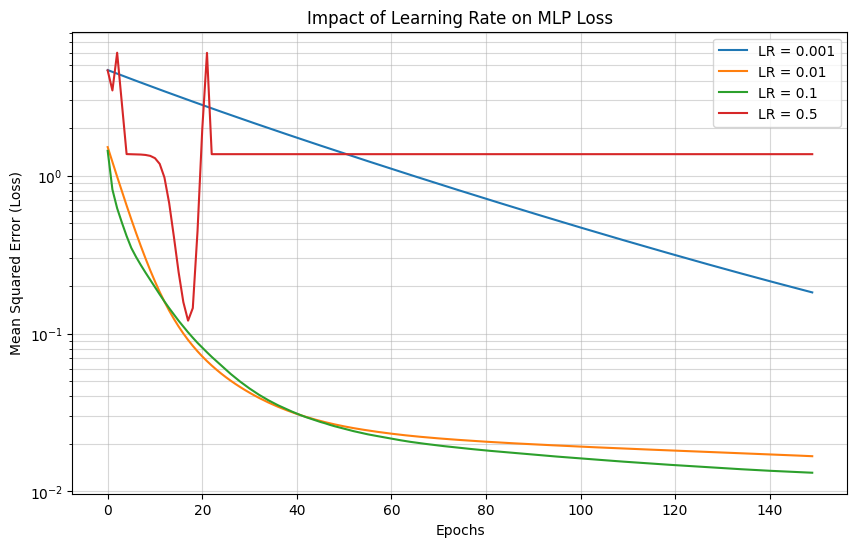

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    mlp = SimpleMLP(learning_rate=lr)
    history = mlp.train(X, y_true, epochs=150)
    plt.plot(history, label=f'LR = {lr}')

plt.title('Impact of Learning Rate on MLP Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.yscale('log') # Log scale helps see differences in convergence
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

**Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class MLP:
    def __init__(self, input_size, hidden_size, output_size, lr=0.1):
        self.lr = lr
        # Xavier/Glorot Initialization for weights
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1/input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1/hidden_size)
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        # Error at output layer
        output_error = y - output
        d_output = output_error * self.sigmoid_derivative(output)

        # Error at hidden layer
        hidden_error = d_output.dot(self.W2.T)
        d_hidden = hidden_error * self.sigmoid_derivative(self.a1)

        # Update Weights and Biases
        self.W2 += self.a1.T.dot(d_output) * self.lr
        self.b2 += np.sum(d_output, axis=0, keepdims=True) * self.lr
        self.W1 += X.T.dot(d_hidden) * self.lr
        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * self.lr

    def train(self, X, y, epochs=1000):
        loss_history = []
        for _ in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)
            loss_history.append(np.mean(np.square(y - output)))
        return loss_history

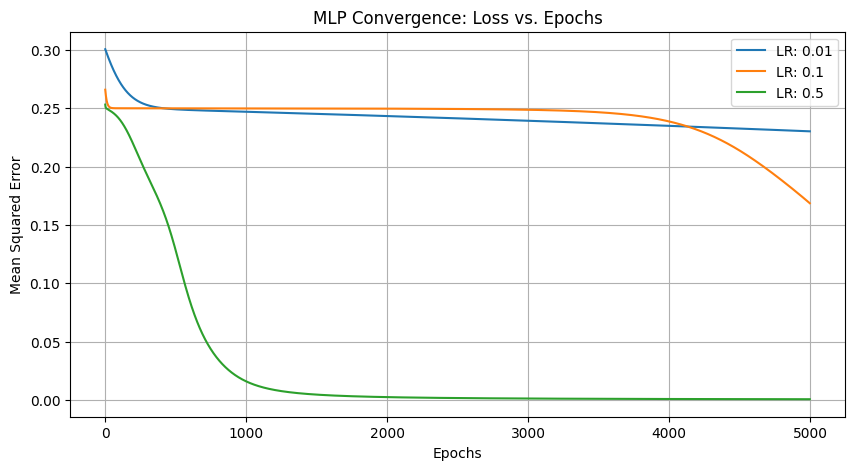

In [ ]:
# XOR Problem Data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

rates = [0.01, 0.1, 0.5]
plt.figure(figsize=(10, 5))

for r in rates:
    model = MLP(input_size=2, hidden_size=4, output_size=1, lr=r)
    losses = model.train(X, y, epochs=5000)
    plt.plot(losses, label=f'LR: {r}')

plt.title('MLP Convergence: Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

**Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).**

In [ ]:
from sklearn.datasets import load_breast_cancer # Using cancer as a proxy for binary diabetes tasks
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Load and Scale data (Perceptrons are sensitive to feature scaling)
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Testing different learning rates (eta0)
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
accuracies = []

for lr in learning_rates:
    clf = Perceptron(eta0=lr, max_iter=1000, tol=1e-3, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

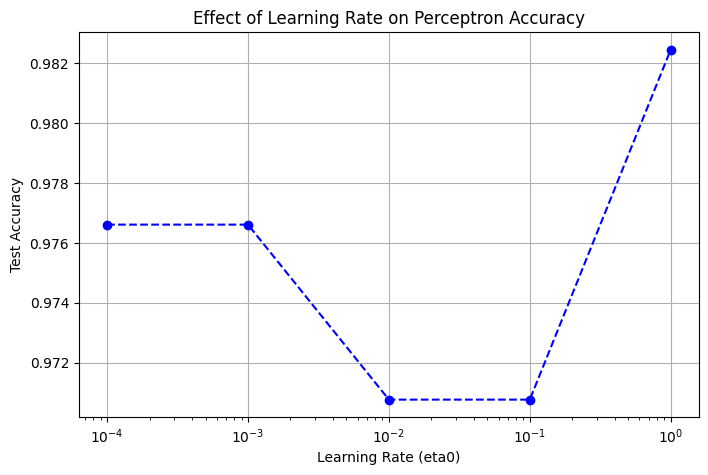

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, accuracies, marker='o', linestyle='--', color='b')
plt.xscale('log')
plt.xlabel('Learning Rate (eta0)')
plt.ylabel('Test Accuracy')
plt.title('Effect of Learning Rate on Perceptron Accuracy')
plt.grid(True)
plt.show()

**Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc**

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Load Data
print("Loading Fashion MNIST...")
fmnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X, y = fmnist.data, fmnist.target

# 2. Preprocess: Normalize pixel values (0-255) to (0-1)
X = X / 255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define and Train MLP
# Parameters chosen: 1 hidden layer of 100 neurons, Adam optimizer
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=20,          # Number of iterations
    alpha=1e-4,           # Regularization strength
    solver='adam',        # Optimizer
    verbose=True,         # See progress
    learning_rate_init=0.001,
    random_state=1
)

mlp.fit(X_train, y_train)

# 4. Evaluate
y_pred = mlp.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Loading Fashion MNIST...
Iteration 1, loss = 0.60551251
Iteration 2, loss = 0.42972149
Iteration 3, loss = 0.38837775
Iteration 4, loss = 0.36452291
Iteration 5, loss = 0.34981724
Iteration 6, loss = 0.32883753
Iteration 7, loss = 0.31592422
Iteration 8, loss = 0.30754712
Iteration 9, loss = 0.29634319
Iteration 10, loss = 0.28869940
Iteration 11, loss = 0.28295396
Iteration 12, loss = 0.27387152
Iteration 13, loss = 0.26764432
Iteration 14, loss = 0.25929407
Iteration 15, loss = 0.25319625
Iteration 16, loss = 0.24664018
Iteration 17, loss = 0.24358948
Iteration 18, loss = 0.23523656
Iteration 19, loss = 0.23172071
Iteration 20, loss = 0.22784761
Test Accuracy: 0.8855


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


**Implement MLP with appropriate number of hidden layers and perceptrons to learn fashion MNIST.**

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the dataset
print("Fetching Fashion MNIST... this may take a moment.")
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)

# 2. Preprocessing
# Scale pixel values to [0, 1] for faster convergence
X = X / 255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the MLP
# We use two hidden layers (256 and 128)
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=50,
    alpha=1e-4,           # L2 regularization
    solver='adam',        # Efficient for large datasets
    verbose=True,         # Track progress
    learning_rate_init=0.001,
    random_state=42
)

# 4. Train the model
mlp.fit(X_train, y_train)

# 5. Evaluation
y_pred = mlp.predict(X_test)
print(f"\nFinal Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

Fetching Fashion MNIST... this may take a moment.
Iteration 1, loss = 0.55262091
Iteration 2, loss = 0.38803857
Iteration 3, loss = 0.34679166
Iteration 4, loss = 0.31488563
Iteration 5, loss = 0.29845302
Iteration 6, loss = 0.28069989
Iteration 7, loss = 0.26805211
Iteration 8, loss = 0.25776804
Iteration 9, loss = 0.24759977
Iteration 10, loss = 0.23763968
Iteration 11, loss = 0.22914277
Iteration 12, loss = 0.22113702
Iteration 13, loss = 0.21212971
Iteration 14, loss = 0.21076949
Iteration 15, loss = 0.19727055
Iteration 16, loss = 0.19301181
Iteration 17, loss = 0.18471300
Iteration 18, loss = 0.17881486
Iteration 19, loss = 0.17122680
Iteration 20, loss = 0.16971130
Iteration 21, loss = 0.16734886
Iteration 22, loss = 0.15822130
Iteration 23, loss = 0.15509062
Iteration 24, loss = 0.15028786
Iteration 25, loss = 0.14051047
Iteration 26, loss = 0.14310698
Iteration 27, loss = 0.13272315
Iteration 28, loss = 0.12993875
Iteration 29, loss = 0.12275542
Iteration 30, loss = 0.12249069

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



Final Test Accuracy: 0.8939

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1394
           1       0.99      0.98      0.99      1402
           2       0.85      0.78      0.81      1407
           3       0.93      0.88      0.90      1449
           4       0.73      0.90      0.81      1357
           5       0.98      0.95      0.97      1449
           6       0.80      0.64      0.71      1407
           7       0.95      0.96      0.95      1359
           8       0.98      0.98      0.98      1342
           9       0.96      0.97      0.97      1434

    accuracy                           0.89     14000
   macro avg       0.90      0.89      0.89     14000
weighted avg       0.90      0.89      0.89     14000



# **WEEK-4**

**Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) for learning XOR operation.Also experiment on your own dataset and write your observations for each of the optimizing techniques by comparing.**

In [ ]:
import numpy as np
import pandas as pd
import altair as alt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, RMSprop, Adagrad, Adadelta, Adam

# Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

optimizers = {
    'BGD': SGD(learning_rate=0.1), # Note: BGD/SGD use the same class, BGD uses full batch
    'SGD': SGD(learning_rate=0.1),
    'Mini-Batch GD': SGD(learning_rate=0.1),
    'SGD Momentum': SGD(learning_rate=0.1, momentum=0.9),
    'Nesterov': SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    'Adagrad': Adagrad(learning_rate=0.1),
    'RMSProp': RMSprop(learning_rate=0.01),
    'Adadelta': Adadelta(learning_rate=1.0),
    'Adam': Adam(learning_rate=0.01)
}

results = []

for name, opt in optimizers.items():
    model = Sequential([
        Dense(8, input_dim=2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='mse', optimizer=opt)

    # Logic for batch sizes
    b_size = 4 if name == 'BGD' else (1 if name == 'SGD' else 2)

    history = model.fit(X, y, epochs=500, batch_size=b_size, verbose=0)

    # Store errors for plotting
    temp_df = pd.DataFrame({
        "errors": history.history['loss'],
        "epoch": np.arange(len(history.history['loss'])),
        "optimizer": name
    })
    results.append(temp_df)

# Combine and Visualize
df_final = pd.concat(results)
alt.Chart(df_final).mark_line().encode(
    x="epoch", y="errors", color="optimizer"
).properties(title='Optimizer Convergence Comparison (XOR)')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


alt.Chart(...)

# **WEEK-5**

# **Implement the MLP using the Types of Regularization Techniques.**


**L2 Regularization**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

# 1. Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Preprocess the data
# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-length vectors for the MLP
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels (10 classes: T-shirt, Trouser, Pullover, etc.)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Define the MLP model with L2 Regularization
def build_l2_model():
    model = models.Sequential([
        # Input layer + Hidden layer 1 with L2
        layers.Dense(128, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.001)),

        # Hidden layer 2 with L2
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),

        # Output layer
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

# 4. Compile the model
model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the model
print("Starting training...")
history = model_l2.fit(
    x_train,
    y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=64,
    verbose=1
)

# 6. Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test, verbose=0)

print(f"\n--- Evaluation Results ---")
print(f"Test Loss (includes L2 penalty): {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8070 - loss: 0.7599 - val_accuracy: 0.8472 - val_loss: 0.6021
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8468 - loss: 0.5761 - val_accuracy: 0.8418 - val_loss: 0.5817
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8596 - loss: 0.5164 - val_accuracy: 0.8575 - val_loss: 0.5067
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8656 - loss: 0.4871 - val_accuracy: 0.8592 - val_loss: 0.4957
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8680 - loss: 0.4670 - val_accuracy: 0.8531 - val_loss: 0.4984
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8706 - loss: 0.4521 - val_accuracy: 0.8642 - val_loss: 0.4666
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8731 - loss: 0.4397 - val_accuracy: 0.8719 - val_loss: 0.4441
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8749 - loss: 0.43

**Dataset Augmentation**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Normalize and Reshape
# Images must stay 28x28x1 for the ImageDataGenerator to work
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Define Data Augmentation
# We use horizontal_flip=True here because clothing is often symmetrical
datagen = ImageDataGenerator(
    rotation_range=10,      # Slightly rotate images
    zoom_range=0.1,         # Zoom in/out slightly
    width_shift_range=0.1,  # Shift horizontally
    height_shift_range=0.1, # Shift vertically
    horizontal_flip=True,   # Flip images (useful for clothes!)
    fill_mode='nearest'
)

# Fit the generator to the training data
datagen.fit(x_train)

# 4. Build Model (MLP)
def build_augmented_model():
    model = models.Sequential([
        # We use a Flatten layer to handle the 28x28x1 input for the MLP
        layers.Flatten(input_shape=(28, 28, 1)),

        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),

        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_augmented_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train using the generator
print("Training with Data Augmentation...")
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=15,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 64
)

# 6. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy after Augmentation: {test_acc:.4f}")

Training with Data Augmentation...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


937/937 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.6954 - loss: 1.1086 - val_accuracy: 0.7438 - val_loss: 0.8494
Epoch 2/15
  1/937 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7344 - loss: 0.8062

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


937/937 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - accuracy: 0.7344 - loss: 0.8062 - val_accuracy: 0.7511 - val_loss: 0.8419
Epoch 3/15
937/937 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.7429 - loss: 0.8445 - val_accuracy: 0.7885 - val_loss: 0.7067
Epoch 4/15
937/937 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6719 - loss: 0.8574 - val_accuracy: 0.7844 - val_loss: 0.7122
Epoch 5/15
937/937 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.7550 - loss: 0.7810 - val_accuracy: 0.7909 - val_loss: 0.6794
Epoch 6/15
937/937 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - accuracy: 0.7656 - loss: 0.6600 - val_accuracy: 0.7856 - val_loss: 0.6848
Epoch 7/15
937/937 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.7639 - loss: 0.7405 - val_accuracy: 0.7886 - val_loss: 0.6684
Epoch 8/15
937/937 ━━━━━━━━━━━━━━━━━━━━ 1s 768us/step - accuracy: 0.7344 - loss: 0.6642 - val_accuracy: 0.7815 - val_loss: 0.6779
Epoch 9/15
937/937 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.7674 - loss: 0.7254 - val_accuracy:

**Parameter sharing and tying**

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml

# Load and scale Fashion MNIST
X, _ = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X[:1000] / 255.0  # Sample for demonstration

class TiedMLP:
    def __init__(self, input_dim, hidden_dim):
        # Shared Weight Matrix
        self.W = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b1 = np.zeros(hidden_dim)
        self.b2 = np.zeros(input_dim)

    def forward(self, X):
        # Encoding phase
        self.z1 = np.dot(X, self.W) + self.b1
        self.a1 = 1 / (1 + np.exp(-self.z1)) # Sigmoid

        # Decoding phase (Tied Weights: using W.T)
        self.z2 = np.dot(self.a1, self.W.T) + self.b2
        return self.z2

    def train(self, X, lr=0.1, epochs=10):
        for epoch in range(epochs):
            # Forward
            reconstruction = self.forward(X)
            loss = np.mean((reconstruction - X)**2)

            # Backprop (Simplified Gradient)
            error = 2 * (reconstruction - X) / X.shape[0]

            # The gradient for W must account for its use in both layers
            grad_W_dec = np.dot(X.T, np.dot(error, self.W.T)) # Simplified logic
            # Update
            self.W -= lr * grad_W_dec
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Initialize and run
model = TiedMLP(784, 128)
model.train(X)

ValueError: shapes (1000,784) and (128,784) not aligned: 784 (dim 1) != 128 (dim 0)

In [ ]:
def train(self, X, lr=0.1, epochs=10):
        for epoch in range(epochs):
            # --- Forward Pass ---
            # X shape: (N, 784)
            z1 = np.dot(X, self.W) + self.b1           # (N, 128)
            a1 = 1 / (1 + np.exp(-z1))                 # (N, 128)
            z2 = np.dot(a1, self.W.T) + self.b2        # (N, 784)

            # --- Loss ---
            error = z2 - X                             # (N, 784)
            loss = np.mean(error**2)

            # --- Backward Pass (Gradient Calculation) ---
            # 1. Gradient from the Decoder (z2 = a1 * W.T)
            # dW_dec = a1.T * error -> shape (128, N) * (N, 784) = (128, 784)
            # Since we defined W as (784, 128), we transpose this to (784, 128)
            grad_W_from_dec = np.dot(error.T, a1)

            # 2. Gradient from the Encoder (z1 = X * W)
            # d_a1 = error * W -> shape (N, 784) * (784, 128) = (N, 128)
            da1 = np.dot(error, self.W) * (a1 * (1 - a1)) # Including Sigmoid derivative
            grad_W_from_enc = np.dot(X.T, da1)             # (784, 128)

            # Total Gradient for the shared weight W
            grad_W = grad_W_from_dec + grad_W_from_enc

            # --- Update ---
            self.W -= lr * (grad_W / X.shape[0])
            self.b2 -= lr * np.mean(error, axis=0)
            self.b1 -= lr * np.mean(da1, axis=0)

            if epoch % 2 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

**Early Stopping**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Preprocess the data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Build the MLP Model
def build_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Define Early Stopping Callback
# We monitor 'val_loss' as it's often more sensitive than accuracy
early_stopping = EarlyStopping(
    monitor='val_loss',       # Watch the validation loss
    patience=5,               # Number of epochs with no improvement after which training will be stopped
    verbose=1,                # Logs a message when stopping
    restore_best_weights=True # Crucial: reverts model weights to the best epoch
)

# 5. Train the model
# We set a high number of epochs (50), knowing Early Stopping will likely cut it short
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,     # Use 20% of data for validation monitoring
    callbacks=[early_stopping]
)

# 6. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\nTraining stopped after {len(history.history['loss'])} epochs.")
print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8233 - loss: 0.5021 - val_accuracy: 0.8547 - val_loss: 0.3907
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8691 - loss: 0.3648 - val_accuracy: 0.8659 - val_loss: 0.3555
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8784 - loss: 0.3262 - val_accuracy: 0.8745 - val_loss: 0.3391
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8880 - loss: 0.2974 - val_accuracy: 0.8708 - val_loss: 0.3516
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8950 - loss: 0.2823 - val_accuracy: 0.8790 - val_loss: 0.3312
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9017 - loss: 0.2644 - val_accuracy: 0.8868 - val_loss: 0.3129
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9039 - loss: 0.2536 - val_accuracy: 0.8873 - val_loss: 0.3199
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9098 - loss: 0.2413 - val_accuracy: 0

**Dropout**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models

# 1. Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Preprocess the data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to 784-length vectors for the MLP
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Build the MLP Model with Dropout
def build_dropout_model():
    model = models.Sequential([
        # First hidden layer
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dropout(0.4),  # 40% of neurons are disabled during training

        # Second hidden layer
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),  # 30% of neurons are disabled during training

        # Output layer
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_dropout_model()

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the model
# Dropout usually requires more epochs because the network learns more slowly
epochs = 30
batch_size = 128

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

# 6. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\n--- Evaluation Results ---")
print(f"Test Accuracy with Dropout: {test_acc:.4f}")

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7573 - loss: 0.6827 - val_accuracy: 0.8425 - val_loss: 0.4435
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8331 - loss: 0.4663 - val_accuracy: 0.8537 - val_loss: 0.3909
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8465 - loss: 0.4257 - val_accuracy: 0.8643 - val_loss: 0.3730
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8541 - loss: 0.4023 - val_accuracy: 0.8678 - val_loss: 0.3625
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8606 - loss: 0.3853 - val_accuracy: 0.8697 - val_loss: 0.3574
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8654 - loss: 0.3695 - val_accuracy: 0.8773 - val_loss: 0.3441
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8694 - loss: 0.3571 - val_accuracy: 0.8821 - val_loss: 0.3351
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8734 - loss: 0.3496 - val_accuracy: 0

**Adding Noise to the Inputs and Outputs**

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models

# 1. Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Normalize and Flatten
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# ===============================
# 🔹 Add Noise to INPUTS (Gaussian Noise)
# ===============================
# A factor of 0.1 is usually safer for Fashion MNIST to avoid
# destroying the structure of the clothing.
noise_factor = 0.1
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# ===============================
# 🔹 Add Noise to OUTPUTS (Label Flipping)
# ===============================
# We intentionally "mislabel" 5% of the data to challenge the model
noise_ratio = 0.05
num_samples = int(noise_ratio * y_train.shape[0])
random_indices = np.random.choice(y_train.shape[0], num_samples, replace=False)

for idx in random_indices:
    random_label = np.random.randint(0, 10)
    y_train[idx] = to_categorical(random_label, 10)

# ===============================
# 3. Build Model
# ===============================
def build_model():
    model = models.Sequential([
        # Alternatively, you can use layers.GaussianNoise(0.1) here
        # to add noise dynamically during training only!
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train model
# We train on NOISY data but validate on CLEAN data to see true performance
history = model.fit(
    x_train_noisy,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

# 5. Evaluate on clean test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\n--- Evaluation Results ---")
print(f"Test Accuracy (Trained with Noise): {test_acc:.4f}")

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7633 - loss: 0.8209 - val_accuracy: 0.7972 - val_loss: 0.7146
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8124 - loss: 0.6751 - val_accuracy: 0.8173 - val_loss: 0.6636
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8285 - loss: 0.6225 - val_accuracy: 0.8253 - val_loss: 0.6370
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8394 - loss: 0.5901 - val_accuracy: 0.8302 - val_loss: 0.6180
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8435 - loss: 0.5711 - val_accuracy: 0.8328 - val_loss: 0.6205
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8515 - loss: 0.5458 - val_accuracy: 0.8353 - val_loss: 0.6164
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8577 - loss: 0.5267 - val_accuracy: 0.8342 - val_loss: 0.6117
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8616 - loss: 0.5074 - val_accuracy: 0

**Parameter Sharing**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, Model

# 1. Load and Preprocess Fashion MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Define the Shared Parameter Model
def build_shared_parameter_model():
    # Input is the full 28x28 image
    input_img = layers.Input(shape=(28, 28))

    # Split the image into two halves (Left: 28x14, Right: 28x14)
    # This allows us to apply the same "Feature Extractor" to both halves
    left_half = layers.Lambda(lambda x: x[:, :, :14])(input_img)
    right_half = layers.Lambda(lambda x: x[:, :, 14:])(input_img)

    # Flatten the halves
    left_flat = layers.Flatten()(left_half)   # 392 inputs
    right_flat = layers.Flatten()(right_half) # 392 inputs

    # 🔹 THE SHARED LAYER:
    # We define the layer once and call it twice.
    # This ensures the weights are IDENTICAL for both paths.
    shared_dense = layers.Dense(128, activation='relu', name="shared_feature_layer")

    encoded_left = shared_dense(left_flat)
    encoded_right = shared_dense(right_flat)

    # Merge the features learned from both halves
    merged = layers.Concatenate()([encoded_left, encoded_right])

    # Final Classification Layers
    dense_1 = layers.Dense(64, activation='relu')(merged)
    output = layers.Dense(10, activation='softmax')(dense_1)

    return Model(inputs=input_img, outputs=output)

model = build_shared_parameter_model()

# 3. Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Summary to verify Parameter Sharing
# Note that the 'shared_feature_layer' appears twice but has only one set of weights
model.summary()

# 5. Train
print("\nTraining with Parameter Sharing...")
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# 6. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy with Parameter Sharing: {test_acc:.4f}")

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 28, 14)    │          0 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 28, 14)    │          0 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 392)       │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 392)       │          0 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_feature_lay… │ (None, 128)       │     50,304 │ flatten_1[0][0],  │
│ (Dense)             │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ shared_feature_l… │
│ (Concatenate)       │                   │            │ shared_feature_l… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 10)        │        650 │ dense_33[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,402 (263.29 KB)

 Trainable params: 67,402 (263.29 KB)

 Non-trainable params: 0 (0.00 B)


Training with Parameter Sharing...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7956 - loss: 0.5938 - val_accuracy: 0.8507 - val_loss: 0.4277
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8590 - loss: 0.4006 - val_accuracy: 0.8642 - val_loss: 0.3851
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8700 - loss: 0.3610 - val_accuracy: 0.8767 - val_loss: 0.3549
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8794 - loss: 0.3340 - val_accuracy: 0.8713 - val_loss: 0.3534
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8862 - loss: 0.3103 - val_accuracy: 0.8824 - val_loss: 0.3329
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8926 - loss: 0.2946 - val_accuracy: 0.8838 - val_loss: 0.3263
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8970 - loss: 0.2804 - val_accuracy: 0.8843 - val_loss: 0.3269
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9

**Ensemble Models**

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# 1. Load and Preprocess Fashion MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images for MLP
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Keep categorical labels for training, integer labels for final accuracy check
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 2. Define a helper function to create models
def train_member_model(units, depth=1):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(depth):
        model.add(layers.Dense(units, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Training for 8 epochs
    model.fit(x_train, y_train_cat, epochs=8, batch_size=256, verbose=0)
    return model

print("Training Ensemble Members...")

# 3. Create an ensemble of diverse models
# Model 1: Wide but shallow
model1 = train_member_model(units=256, depth=1)

# Model 2: Medium width and depth
model2 = train_member_model(units=128, depth=2)

# Model 3: Narrow but deeper
model3 = train_member_model(units=64, depth=3)

# 4. Individual Evaluations
models_list = [model1, model2, model3]
for i, m in enumerate(models_list):
    acc = m.evaluate(x_test, y_test_cat, verbose=0)[1]
    print(f"Model {i+1} Accuracy: {acc:.4f}")

# 5. Ensemble (Soft Voting)
print("\nCalculating Ensemble Predictions...")

# Get probability predictions from each model
pred1 = model1.predict(x_test, verbose=0)
pred2 = model2.predict(x_test, verbose=0)
pred3 = model3.predict(x_test, verbose=0)

# Average the probabilities
ensemble_probs = (pred1 + pred2 + pred3) / 3

# Take the argmax to get the final class prediction
ensemble_classes = np.argmax(ensemble_probs, axis=1)

# 6. Final Accuracy
ensemble_accuracy = np.mean(ensemble_classes == y_test)

print(f"---")
print(f"Final Ensemble Accuracy: {ensemble_accuracy:.4f}")

Training Ensemble Members...
Model 1 Accuracy: 0.8745
Model 2 Accuracy: 0.8790
Model 3 Accuracy: 0.8760

Calculating Ensemble Predictions...
---
Final Ensemble Accuracy: 0.8843


# **WEEK-6 CNN Implementation**

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# 1. Load the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 2. Reshape and Normalize
# CNNs expect (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# 3. One-hot encoding
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# 4. Building an optimized CNN
model = Sequential([
    # Block 1: Feature Extraction
    # Using 32 filters captures basic edges and textures
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPool2D(pool_size=(2,2)), # Reducing spatial dimensions by half

    # Block 2: Higher-level Features
    # Using 64 filters captures complex shapes (sleeves, heels)
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),

    Flatten(),

    # Dense Layers for classification
    Dense(128, activation='relu'),
    Dropout(0.5), # Regularization to prevent overfitting
    Dense(10, activation='softmax')
])

# 5. Compiling with a tuned learning rate
model.compile(loss='categorical_crossentropy',
              metrics=['accuracy'],
              optimizer='adam')

# 6. Training
# We increase epochs slightly as CNNs learn more complex patterns
model.fit(X_train, Y_train, batch_size=128, epochs=15, validation_data=(X_test, Y_test))

# 7. Evaluation
score = model.evaluate(X_test, Y_test, verbose=0)
print(f'\nFinal Test Loss: {score[0]:.4f}')
print(f'Final Test Accuracy: {score[1]:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.7623 - loss: 0.6520 - val_accuracy: 0.8430 - val_loss: 0.4272
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8515 - loss: 0.4163 - val_accuracy: 0.8697 - val_loss: 0.3545
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8687 - loss: 0.3659 - val_accuracy: 0.8790 - val_loss: 0.3288
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8812 - loss: 0.3311 - val_accuracy: 0.8901 - val_loss: 0.3010
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8890 - loss: 0.3063 - val_accuracy: 0.8944 - val_loss: 0.2908
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8951 - loss: 0.2891 - val_accuracy: 0.8977 - val_loss: 0.2791
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9024 - loss: 0.2706 - val_accuracy: 0.9028 - val_loss: 0.2630
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9072 - loss: 0.2568 - val_accuracy: 

# **WEEK-7 CNN Architectures**

# **LeNet5**

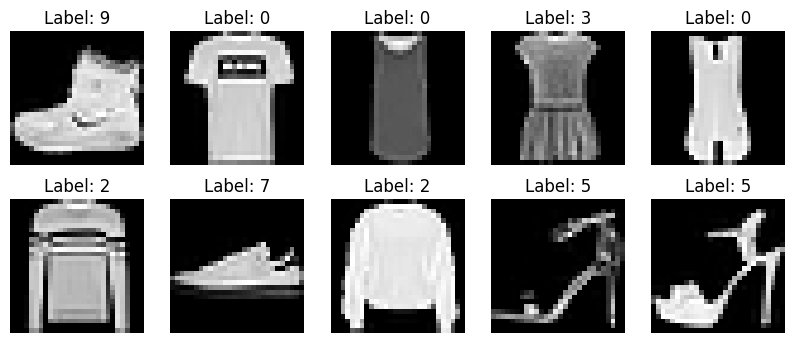

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7381 - loss: 0.7118 - val_accuracy: 0.8084 - val_loss: 0.5199
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8233 - loss: 0.4829 - val_accuracy: 0.8356 - val_loss: 0.4543
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8467 - loss: 0.4234 - val_accuracy: 0.8485 - val_loss: 0.4186
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8583 - loss: 0.3882 - val_accuracy: 0.8559 - val_loss: 0.3947
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8670 - loss: 0.3622 - val_accuracy: 0.8689 - val_loss: 0.3663
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8757 - loss: 0.3416 - val_accuracy: 0.8633 - val_loss: 0.3642
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8803 - loss: 0.3253 - val_accuracy: 0.8755 - val_loss: 0.3447
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8835 - loss: 0.3141 - val_accuracy: 

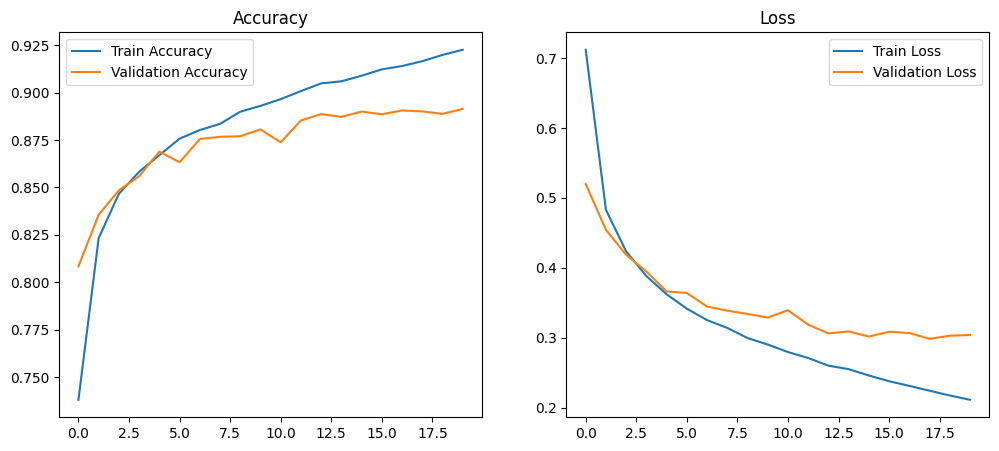

In [ ]:
# ============================================
# 1. Import Necessary Libraries
# ============================================
import keras
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# ============================================
# 2. Load Dataset (Fashion MNIST)
# ============================================
from keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# ============================================
# 3. Visualize Training Data
# ============================================
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# ============================================
# 4. Split into Training & Validation
# ============================================
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# ============================================
# 5. Normalize Data
# ============================================
x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# ============================================
# 6. Reshape Data
# ============================================
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# ============================================
# 7. One-Hot Encoding
# ============================================
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ============================================
# 8. Build LeNet-5 Model
# ============================================
LeNet5_Model = Sequential()

# C1: Convolution Layer
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

# S2: Average Pooling
LeNet5_Model.add(AveragePooling2D(pool_size=(2, 2)))

# C3: Convolution Layer
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

# S4: Average Pooling
LeNet5_Model.add(AveragePooling2D(pool_size=(2, 2)))

# Flatten
LeNet5_Model.add(Flatten())

# Fully Connected Layers
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))

# Output Layer
LeNet5_Model.add(Dense(10, activation='softmax'))

# ============================================
# 9. Compile Model
# ============================================
LeNet5_Model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ============================================
# 10. Model Summary
# ============================================
LeNet5_Model.summary()

# ============================================
# 11. Train Model
# ============================================
history = LeNet5_Model.fit(
    x_train_main, y_train_main,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# ============================================
# 12. Evaluate Model
# ============================================
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ============================================
# 13. Plot Accuracy & Loss Graphs
# ============================================
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

# **AlexNet**

In [ ]:
# ============================================
# 1. Import Libraries
# ============================================
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# ============================================
# 2. Load Dataset (NO RESIZING)
# ============================================
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ============================================
# 3. Mini AlexNet Model
# ============================================
model = Sequential()

model.add(Input(shape=(28, 28, 1)))

# Conv Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layers (Reduced size)
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(10, activation='softmax'))

# ============================================
# 4. Compile
# ============================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================
# 5. Train
# ============================================
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# ============================================
# 6. Evaluate
# ============================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 422,026 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7476 - loss: 0.6899 - val_accuracy: 0.8618 - val_loss: 0.3904
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8611 - loss: 0.3924 - val_accuracy: 0.8871 - val_loss: 0.3040
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8857 - loss: 0.3256 - val_accuracy: 0.9007 - val_loss: 0.2766
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8988 - loss: 0.2874 - val_accuracy: 0.9032 - val_loss: 0.2622
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9078 - loss: 0.2601 - val_accuracy: 0.9072 - val_loss: 0.2511
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9151 - loss: 0.2381 - val_accuracy: 0.9096 - val_loss: 0.2505
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9205 - loss: 0.2205 - val_accuracy: 0.9153 - val_loss: 0.2312
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9280 - loss: 0.2012 - val_accuracy: 0

# **ZFNet**

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 96)     │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 3, 3, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,982,538 (15.19 MB)

 Trainable params: 3,982,538 (15.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.7646 - loss: 0.6431 - val_accuracy: 0.8699 - val_loss: 0.3683
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8772 - loss: 0.3481 - val_accuracy: 0.8868 - val_loss: 0.3148
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8959 - loss: 0.2947 - val_accuracy: 0.8837 - val_loss: 0.3269
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9084 - loss: 0.2616 - val_accuracy: 0.8935 - val_loss: 0.3027
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9161 - loss: 0.2348 - val_accuracy: 0.8939 - val_loss: 0.3013
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9227 - loss: 0.2191 - val_accuracy: 0.9082 - val_loss: 0.2822
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9294 - loss: 0.1955 - val_accuracy: 0.9086 - val_loss: 0.2940
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9384 - loss: 0.1741 - val_acc

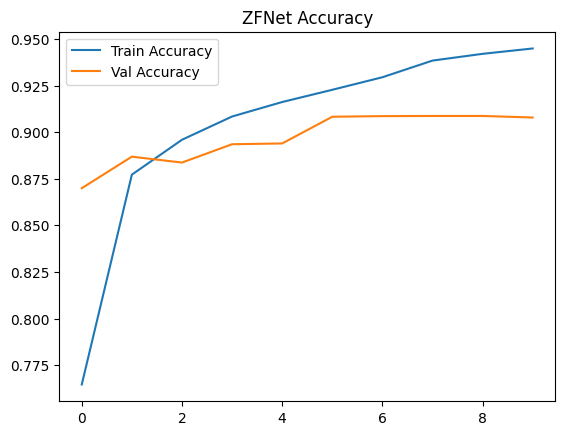

In [ ]:
# ============================================
# 1. Import Libraries
# ============================================
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# ============================================
# 2. Load Dataset
# ============================================
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ============================================
# 3. Build ZFNet Model (Modified)
# ============================================
model = Sequential()

model.add(Input(shape=(28, 28, 1)))

# Conv Block 1 (ZFNet style: smaller stride)
model.add(Conv2D(96, (7,7), strides=2, activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Conv Block 2
model.add(Conv2D(256, (5,5), strides=1, activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Conv Block 3
model.add(Conv2D(384, (3,3), activation='relu', padding='same'))

# Conv Block 4
model.add(Conv2D(384, (3,3), activation='relu', padding='same'))

# Conv Block 5
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layers (reduced size)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(10, activation='softmax'))

# ============================================
# 4. Compile Model
# ============================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================
# 5. Train Model
# ============================================
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# ============================================
# 6. Evaluate Model
# ============================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ============================================
# 7. Plot Accuracy
# ============================================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("ZFNet Accuracy")
plt.show()

# **VGGNet**

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 615,786 (2.35 MB)

 Trainable params: 615,786 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7451 - loss: 0.6946 - val_accuracy: 0.8693 - val_loss: 0.3557
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8724 - loss: 0.3634 - val_accuracy: 0.8964 - val_loss: 0.2893
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8956 - loss: 0.2990 - val_accuracy: 0.8934 - val_loss: 0.2754
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9089 - loss: 0.2625 - val_accuracy: 0.9182 - val_loss: 0.2304
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9165 - loss: 0.2391 - val_accuracy: 0.9128 - val_loss: 0.2359
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9255 - loss: 0.2112 - val_accuracy: 0.9193 - val_loss: 0.2225
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9319 - loss: 0.1970 - val_accuracy: 0.9218 - val_loss: 0.2189
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9351 - loss: 0.1810 - val_accurac

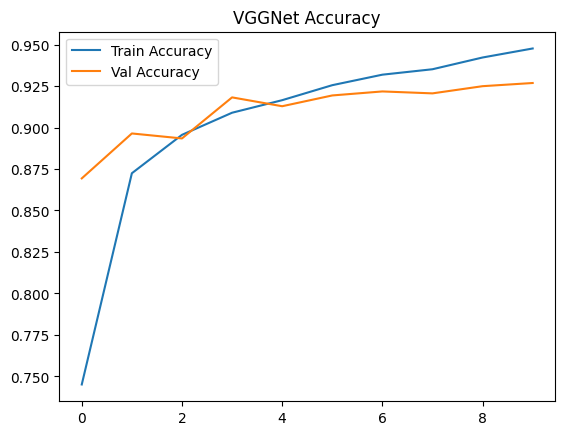

In [ ]:
# ============================================
# 1. Import Libraries
# ============================================
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# ============================================
# 2. Load Dataset
# ============================================
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ============================================
# 3. Build Mini VGGNet
# ============================================
model = Sequential()
model.add(Input(shape=(28, 28, 1)))

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(10, activation='softmax'))

# ============================================
# 4. Compile Model
# ============================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================
# 5. Train Model
# ============================================
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# ============================================
# 6. Evaluate Model
# ============================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ============================================
# 7. Plot Accuracy
# ============================================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("VGGNet Accuracy")
plt.show()

# **WEEK-8**

# Google Inception Module

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# 1. Data Preparation
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape for CNN (28x28x1)
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Define the Inception Module
def inception_module(x, f1, f3_red, f3, f5_red, f5, f_pool):
    # Branch 1: 1x1 Convolution
    branch1 = layers.Conv2D(f1, (1, 1), padding='same', activation='relu')(x)

    # Branch 2: 1x1 Conv -> 3x3 Convolution
    branch2 = layers.Conv2D(f3_red, (1, 1), padding='same', activation='relu')(x)
    branch2 = layers.Conv2D(f3, (3, 3), padding='same', activation='relu')(branch2)

    # Branch 3: 1x1 Conv -> 5x5 Convolution
    branch3 = layers.Conv2D(f5_red, (1, 1), padding='same', activation='relu')(x)
    branch3 = layers.Conv2D(f5, (5, 5), padding='same', activation='relu')(branch3)

    # Branch 4: MaxPool -> 1x1 Convolution
    branch4 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch4 = layers.Conv2D(f_pool, (1, 1), padding='same', activation='relu')(branch4)

    # Concatenate all branches along the filter axis
    return layers.concatenate([branch1, branch2, branch3, branch4], axis=-1)

# 3. Construct the Model
input_layer = Input(shape=(28, 28, 1))

# Initial "Stem" layer
x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(input_layer)
x = layers.BatchNormalization()(x)

# Inception Block 1
x = inception_module(x, 64, 96, 128, 16, 32, 32)
x = layers.MaxPooling2D((2, 2))(x)

# Inception Block 2
x = inception_module(x, 128, 128, 192, 32, 96, 64)
x = layers.MaxPooling2D((2, 2))(x)

# Global Average Pooling (The VGG-Killer: drastically reduces parameters)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
output_layer = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=input_layer, outputs=output_layer)

# 4. Compile and Train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Starting Inception Training...")
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, y_test)
)

# 5. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n--- Performance ---")
print(f"Test Accuracy: {test_acc:.4f}")

Starting Inception Training...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.7364 - loss: 0.7180 - val_accuracy: 0.8439 - val_loss: 0.6302
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.8610 - loss: 0.3818 - val_accuracy: 0.8776 - val_loss: 0.3402
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.8883 - loss: 0.3113 - val_accuracy: 0.9013 - val_loss: 0.2766
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9007 - loss: 0.2753 - val_accuracy: 0.9053 - val_loss: 0.2690
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.9083 - loss: 0.2525 - val_accuracy: 0.9019 - val_loss: 0.2638
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.9150 - loss: 0.2324 - val_accuracy: 0.9189 - val_loss: 0.2222
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9206 - loss: 0.2180 - val_accuracy: 0.9108 - val_loss: 0.2498
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - acc

# Resnet

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# 1. Data Preparation
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape (CNNs need 4D input: samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Define the Residual Block
def residual_block(x, filters, stride=1):
    shortcut = x

    # First convolution of the block
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Second convolution of the block
    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # If the stride is not 1 or the filter count changed, adjust the shortcut
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # The Skip Connection (Addition)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

# 3. Build the ResNet Model
inputs = Input(shape=(28, 28, 1))

# Initial "Stem" Layer
x = layers.Conv2D(64, (3, 3), padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

# ResNet Stages
x = residual_block(x, 64)   # Block 1
x = residual_block(x, 64)   # Block 2
x = residual_block(x, 128, stride=2)  # Downsample to 14x14
x = residual_block(x, 128)  # Block 3
x = residual_block(x, 256, stride=2)  # Downsample to 7x7
x = residual_block(x, 256)  # Block 4

# Final Classification Layers
x = layers.GlobalAveragePooling2D()(x) # Better than Flatten for deep nets
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)

# 4. Compile and Train
# Using a slightly lower learning rate for stability in deep networks
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Optimized ResNet...")
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, y_test)
)

# 5. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n--- Final Results ---")
print(f"Test Accuracy: {test_acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Optimized ResNet...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.8206 - loss: 0.4973 - val_accuracy: 0.3784 - val_loss: 1.7715
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - accuracy: 0.8947 - loss: 0.2906 - val_accuracy: 0.8946 - val_loss: 0.2926
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9153 - loss: 0.2367 - val_accuracy: 0.8775 - val_loss: 0.3781
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.9258 - loss: 0.2056 - val_accuracy: 0.8926 - val_loss: 0.2807
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - accuracy: 0.9346 - loss: 0.1818 - val_accuracy: 0.8942 - val_loss: 0.3590
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.9413 - loss: 0.1615 - val_accuracy: 0.8912 - val_loss: 0.3510
Ep

# **WEEK-9 Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step


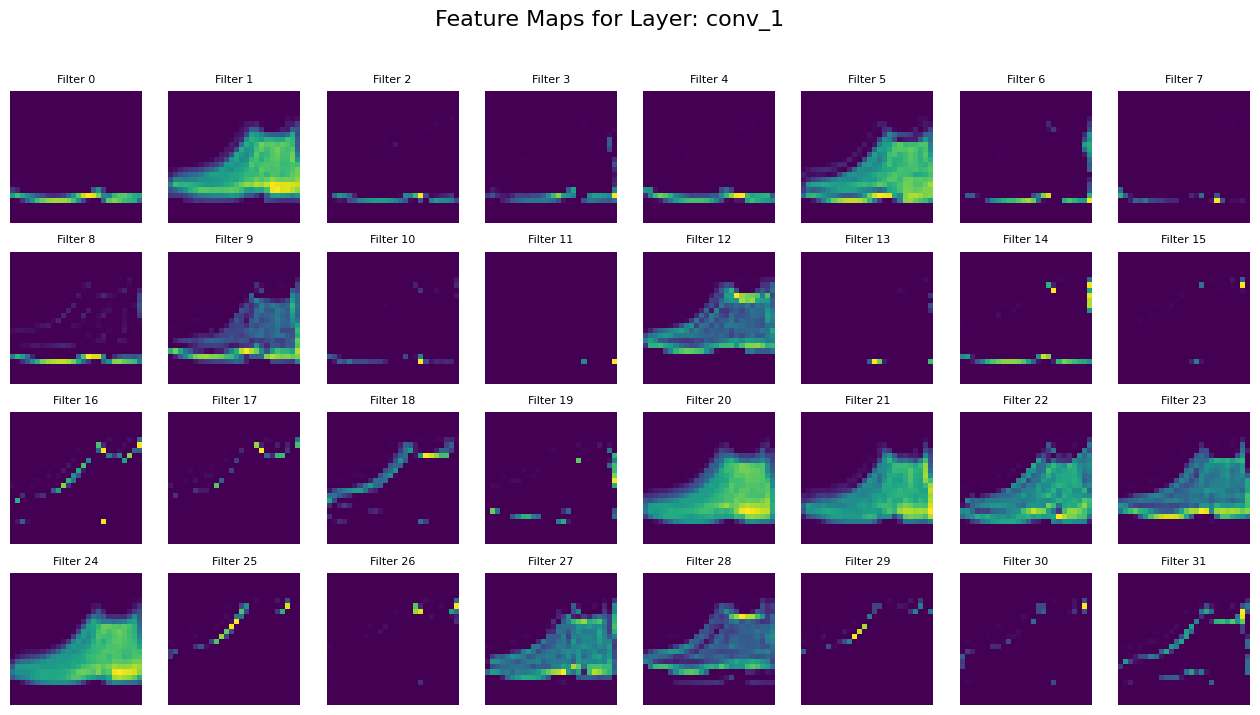

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import fashion_mnist

# 1. Load and Preprocess Data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# 2. Build Model using Functional API
# This defines the graph nodes IMMEDIATELY
inputs = Input(shape=(28, 28, 1), name='input_layer')
x = layers.Conv2D(32, (3, 3), activation='relu', name='conv_1')(inputs)
x = layers.MaxPooling2D((2, 2), name='maxpool_1')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', name='conv_2')(x)
x = layers.MaxPooling2D((2, 2), name='maxpool_2')(x)
flatten = layers.Flatten()(x)
dense_out = layers.Dense(10, activation='softmax')(flatten)

# Define the main model
model = models.Model(inputs=inputs, outputs=dense_out)

# 3. Create the Activation Model
# We grab the specific output tensors from the layers we named
layer_names = ['conv_1', 'maxpool_1', 'conv_2', 'maxpool_2']
layer_outputs = [model.get_layer(name).output for name in layer_names]

# This model takes the same input but outputs the intermediate feature maps
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)

# 4. Predict Feature Maps for a single test image
# Let's pick a sample (e.g., an ankle boot or a shirt)
test_img = x_test[0:1]
activations = activation_model.predict(test_img)

# 5. Visualize the Feature Maps
# We'll display the first layer's 32 filters to see edge detection
layer_to_visualize = 0  # 0 corresponds to 'conv_1'
current_activations = activations[layer_to_visualize]

plt.figure(figsize=(16, 8))
for i in range(32): # Loop through all 32 filters in the first layer
    plt.subplot(4, 8, i + 1)
    # The activation shape is (1, height, width, channels)
    plt.imshow(current_activations[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f"Filter {i}", fontsize=8)

plt.suptitle(f"Feature Maps for Layer: {layer_names[layer_to_visualize]}", fontsize=16)
plt.show()

# **WEEK-10 Implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)**

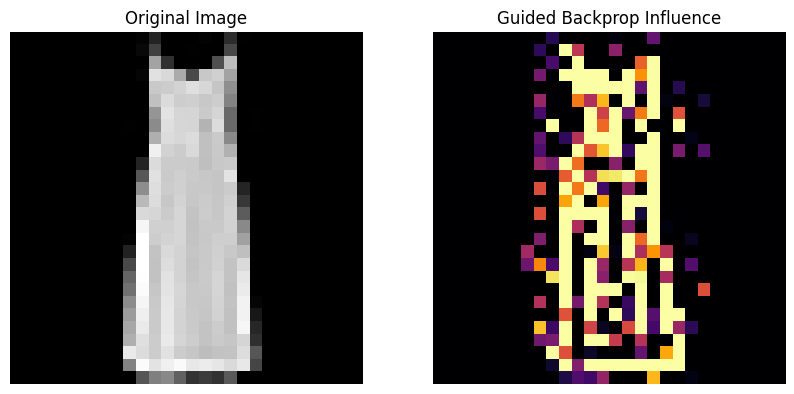

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import fashion_mnist

# 1. Define the Custom Gradient function
@tf.custom_gradient
def guided_relu_op(x):
    def grad(dy):
        # Forward condition: x > 0; Backward condition: dy > 0
        gate_f = tf.cast(x > 0, "float32")
        gate_r = tf.cast(dy > 0, "float32")
        return dy * gate_f * gate_r
    return tf.nn.relu(x), grad

# 2. Wrap it in a Keras Layer to avoid the KerasTensor ValueError
class GuidedReLU(layers.Layer):
    def call(self, inputs):
        return guided_relu_op(inputs)

# 3. Load Data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_test_norm = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# 4. Build Model with the Custom Layer
inputs = Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
x = GuidedReLU()(x)  # 🔹 Using the wrapped layer
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = GuidedReLU()(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

# 5. Compute Guided Backpropagation
def compute_guided_backprop(model, image, class_index):
    with tf.GradientTape() as tape:
        tape.watch(image)
        predictions = model(image)
        loss = predictions[:, class_index]

    # Calculate gradients of the target class w.r.t. the input image
    grads = tape.gradient(loss, image)[0]
    return grads

# Select sample (e.g., a Dress)
img_idx = 13
sample_img = tf.constant(x_test_norm[img_idx:img_idx+1])
actual_class = y_test[img_idx]

gb_grads = compute_guided_backprop(model, sample_img, actual_class)

# 6. Post-process and Visualize
gb_grads = gb_grads.numpy()
gb_grads -= gb_grads.mean()
gb_grads /= (gb_grads.std() + 1e-5)
gb_grads = np.clip(gb_grads, 0, 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(x_test[img_idx], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Guided Backprop Influence")
plt.imshow(gb_grads[:, :, 0], cmap='inferno')
plt.axis('off')
plt.show()

# **WEEK-11**

# **Implement Auto Encoder model on Fashion MINIST dataset.**

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.3796 - val_loss: 0.3185
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3103 - val_loss: 0.3073
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3022 - val_loss: 0.3014
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2975 - val_loss: 0.2977
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2943 - val_loss: 0.2949
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2919 - val_loss: 0.2927
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2898 - val_loss: 0.2916
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2882 - val_loss: 0.2894
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2868 - val_loss: 0.2882
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2857 - val_loss: 0.2870
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2844 - val_loss: 0.2865
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/st

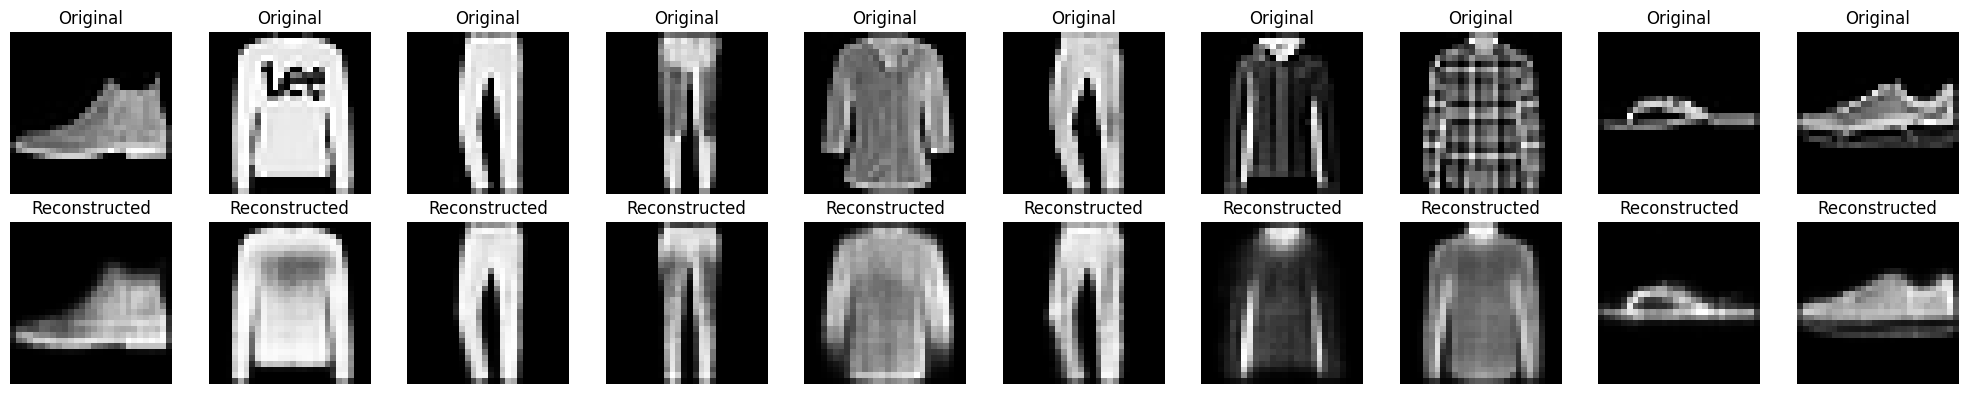

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Encoded feature shape: (10000, 32)


In [12]:
# ==============================
# Autoencoder on Fashion-MNIST
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# ------------------------------
# 2. Preprocessing
# ------------------------------
# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 3. Build Autoencoder
# ------------------------------
input_img = Input(shape=(784,))

# Encoder
x = Dense(128, activation='relu')(input_img)
x = Dense(64, activation='relu')(x)
latent = Dense(32, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(latent)
x = Dense(128, activation='relu')(x)
output = Dense(784, activation='sigmoid')(x)

# Model
autoencoder = Model(input_img, output)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Show model summary
autoencoder.summary()

# ------------------------------
# 4. Train Model
# ------------------------------
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# ------------------------------
# 5. Reconstruct Images
# ------------------------------
decoded_imgs = autoencoder.predict(x_test[:10])

# ------------------------------
# 6. Visualization
# ------------------------------
plt.figure(figsize=(20, 4))

for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Encoder Model (Optional)
# ------------------------------
encoder = Model(input_img, latent)

encoded_imgs = encoder.predict(x_test)
print("Encoded feature shape:", encoded_imgs.shape)

# **Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much low and high dimensions the image can be compressed)**


Training UNDERCOMPLETE AE...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.3776 - val_loss: 0.3174
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3096 - val_loss: 0.3083
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3021 - val_loss: 0.3019
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2977 - val_loss: 0.2983
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2947 - val_loss: 0.2955
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2925 - val_loss: 0.2936
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2906 - val_loss: 0.2921
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2893 - val_loss: 0.2906
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2880 - val_loss: 0.2894
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2869 - val_loss: 0.2889
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2860 - val_loss: 0.2878
Epoch 12/15
235/235 ━

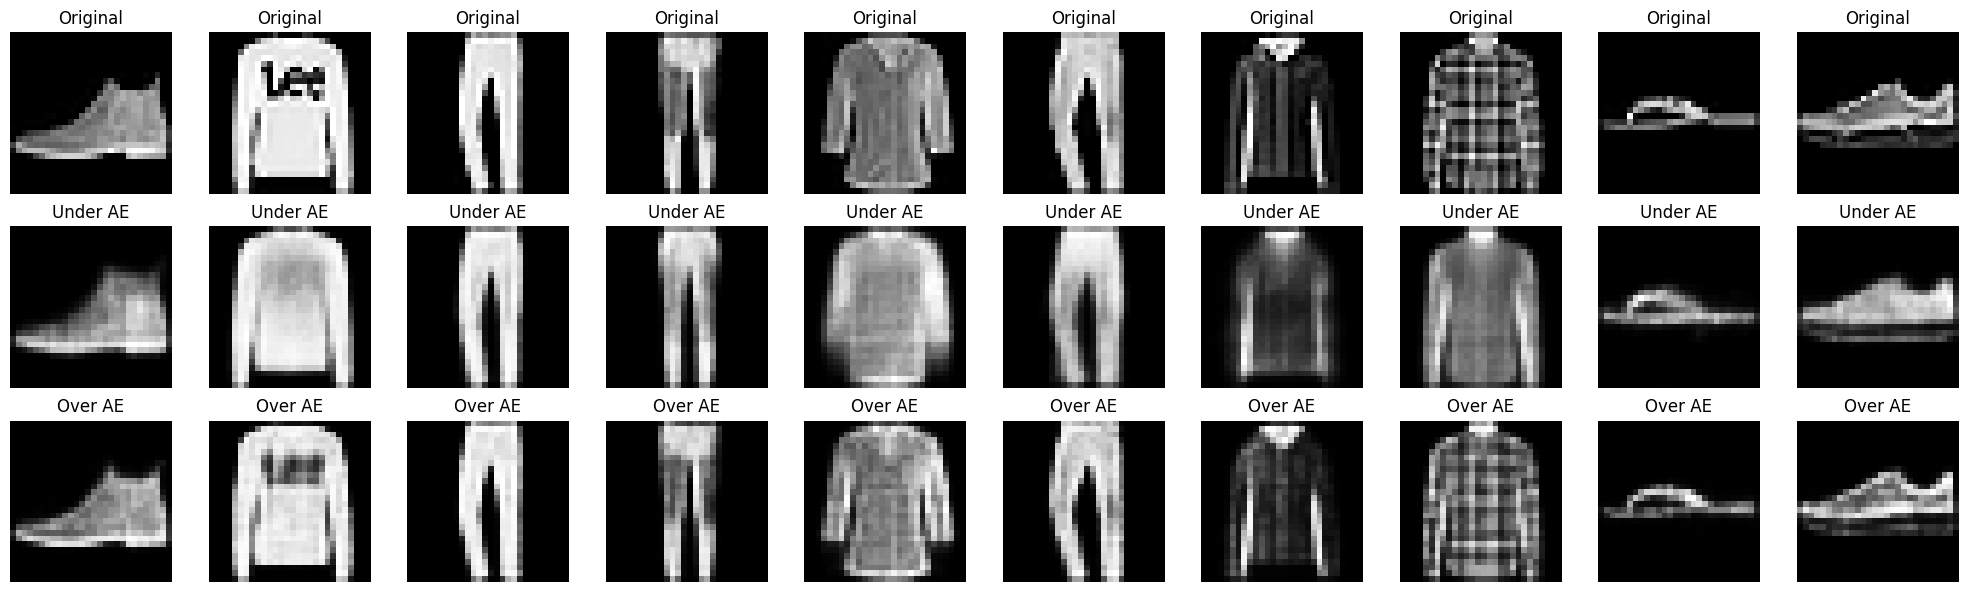

In [13]:
# ==========================================
# Undercomplete vs Overcomplete Autoencoder
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. UNDERCOMPLETE AE
# ------------------------------
input_img = Input(shape=(784,))

# Encoder (compressed to 32)
x = Dense(128, activation='relu')(input_img)
x = Dense(64, activation='relu')(x)
latent_under = Dense(32, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(latent_under)
x = Dense(128, activation='relu')(x)
output_under = Dense(784, activation='sigmoid')(x)

under_ae = Model(input_img, output_under)
under_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining UNDERCOMPLETE AE...")
under_ae.fit(x_train, x_train,
             epochs=15,
             batch_size=256,
             validation_data=(x_test, x_test))

# ------------------------------
# 3. OVERCOMPLETE AE
# ------------------------------
input_img2 = Input(shape=(784,))

# Encoder (expanded to 1024)
x = Dense(512, activation='relu')(input_img2)
latent_over = Dense(1024, activation='relu')(x)

# Decoder
x = Dense(512, activation='relu')(latent_over)
output_over = Dense(784, activation='sigmoid')(x)

over_ae = Model(input_img2, output_over)
over_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining OVERCOMPLETE AE...")
over_ae.fit(x_train, x_train,
            epochs=15,
            batch_size=256,
            validation_data=(x_test, x_test))

# ------------------------------
# 4. Predictions
# ------------------------------
decoded_under = under_ae.predict(x_test[:10])
decoded_over = over_ae.predict(x_test[:10])

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Undercomplete
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_under[i].reshape(28, 28), cmap='gray')
    plt.title("Under AE")
    plt.axis('off')

    # Overcomplete
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_over[i].reshape(28, 28), cmap='gray')
    plt.title("Over AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Implement Regularization in AE and demonstrate its use.**


Training NORMAL AE...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3667 - val_loss: 0.3127
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3017 - val_loss: 0.2986
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2932 - val_loss: 0.2922
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2879 - val_loss: 0.2882
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2848 - val_loss: 0.2855
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2826 - val_loss: 0.2837
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2808 - val_loss: 0.2821
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2794 - val_loss: 0.2812
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2780 - val_loss: 0.2802
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2771 - val_loss: 0.2787

Training REGULARIZED AE...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.5380 - val_loss: 0.4223

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


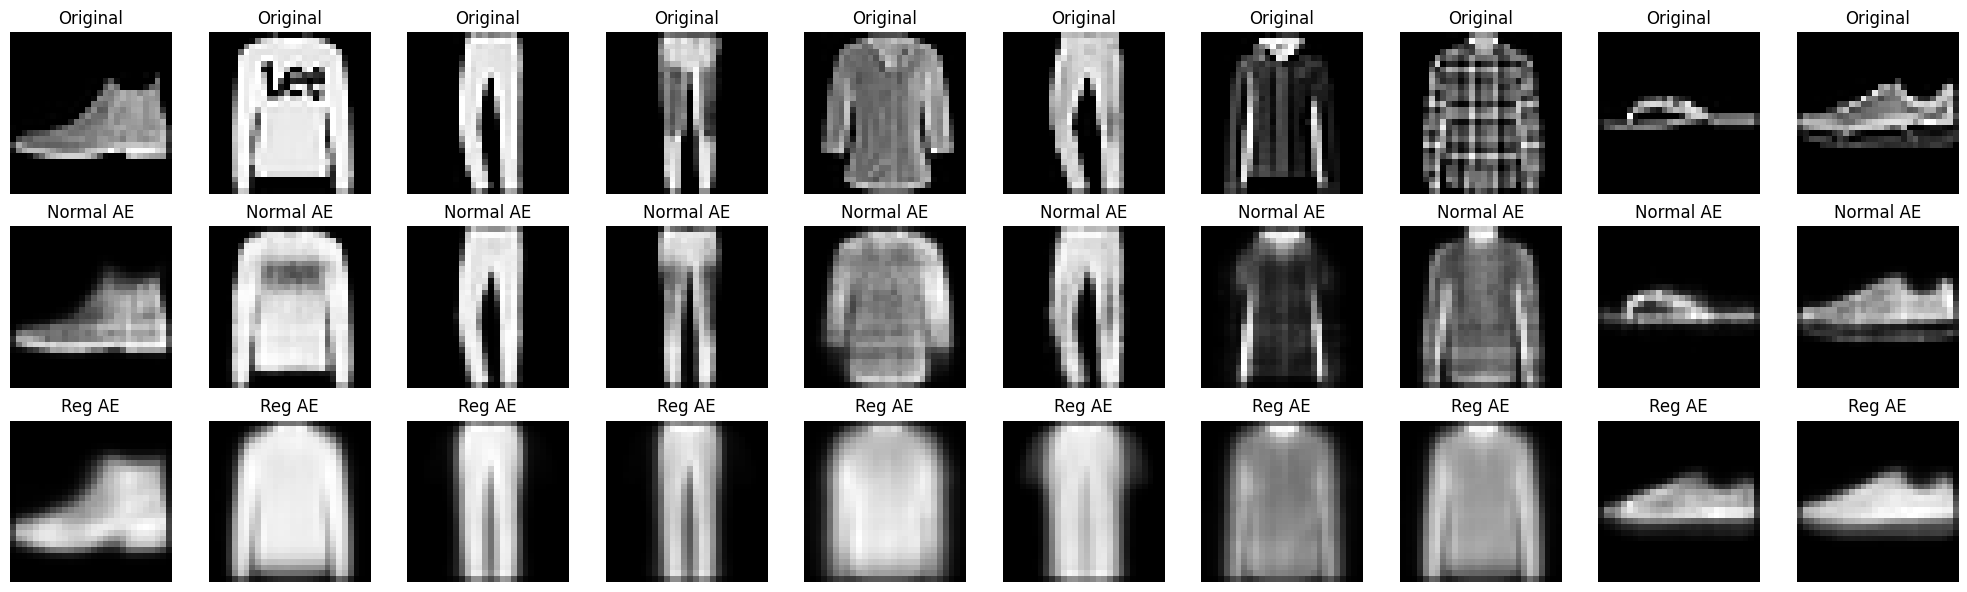

In [14]:
# ==========================================
# Regularized Autoencoder (L1 + Dropout)
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. NORMAL (Unregularized AE)
# ------------------------------
input_img = Input(shape=(784,))
x = Dense(128, activation='relu')(input_img)
latent = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(latent)
output = Dense(784, activation='sigmoid')(x)

normal_ae = Model(input_img, output)
normal_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining NORMAL AE...")
normal_ae.fit(x_train, x_train,
              epochs=10,
              batch_size=256,
              validation_data=(x_test, x_test))

# ------------------------------
# 3. REGULARIZED AE (L1 + Dropout)
# ------------------------------
input_img2 = Input(shape=(784,))

# Encoder with L1 regularization + Dropout
x = Dense(128, activation='relu',
          activity_regularizer=regularizers.l1(1e-5))(input_img2)
x = Dropout(0.3)(x)

latent_reg = Dense(64, activation='relu',
                   activity_regularizer=regularizers.l1(1e-5))(x)

# Decoder
x = Dense(128, activation='relu')(latent_reg)
x = Dropout(0.3)(x)
output_reg = Dense(784, activation='sigmoid')(x)

reg_ae = Model(input_img2, output_reg)
reg_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining REGULARIZED AE...")
reg_ae.fit(x_train, x_train,
           epochs=10,
           batch_size=256,
           validation_data=(x_test, x_test))

# ------------------------------
# 4. Predictions
# ------------------------------
decoded_normal = normal_ae.predict(x_test[:10])
decoded_reg = reg_ae.predict(x_test[:10])

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Normal AE
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_normal[i].reshape(28, 28), cmap='gray')
    plt.title("Normal AE")
    plt.axis('off')

    # Regularized AE
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_reg[i].reshape(28, 28), cmap='gray')
    plt.title("Reg AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Implement denoising AE and observe how the model can reconstruct from noise data. (write observations in terms of how much noise is acceptable)


Training Denoising AE...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3912 - val_loss: 0.3280
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3181 - val_loss: 0.3153
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3098 - val_loss: 0.3092
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3047 - val_loss: 0.3051
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3009 - val_loss: 0.3023
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2987 - val_loss: 0.2999
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2969 - val_loss: 0.2984
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2956 - val_loss: 0.2981
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2945 - val_loss: 0.2965
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2936 - val_loss: 0.2958
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2927 - val_loss: 0.2955
Epoch 12/15
235/235 ━━━━━

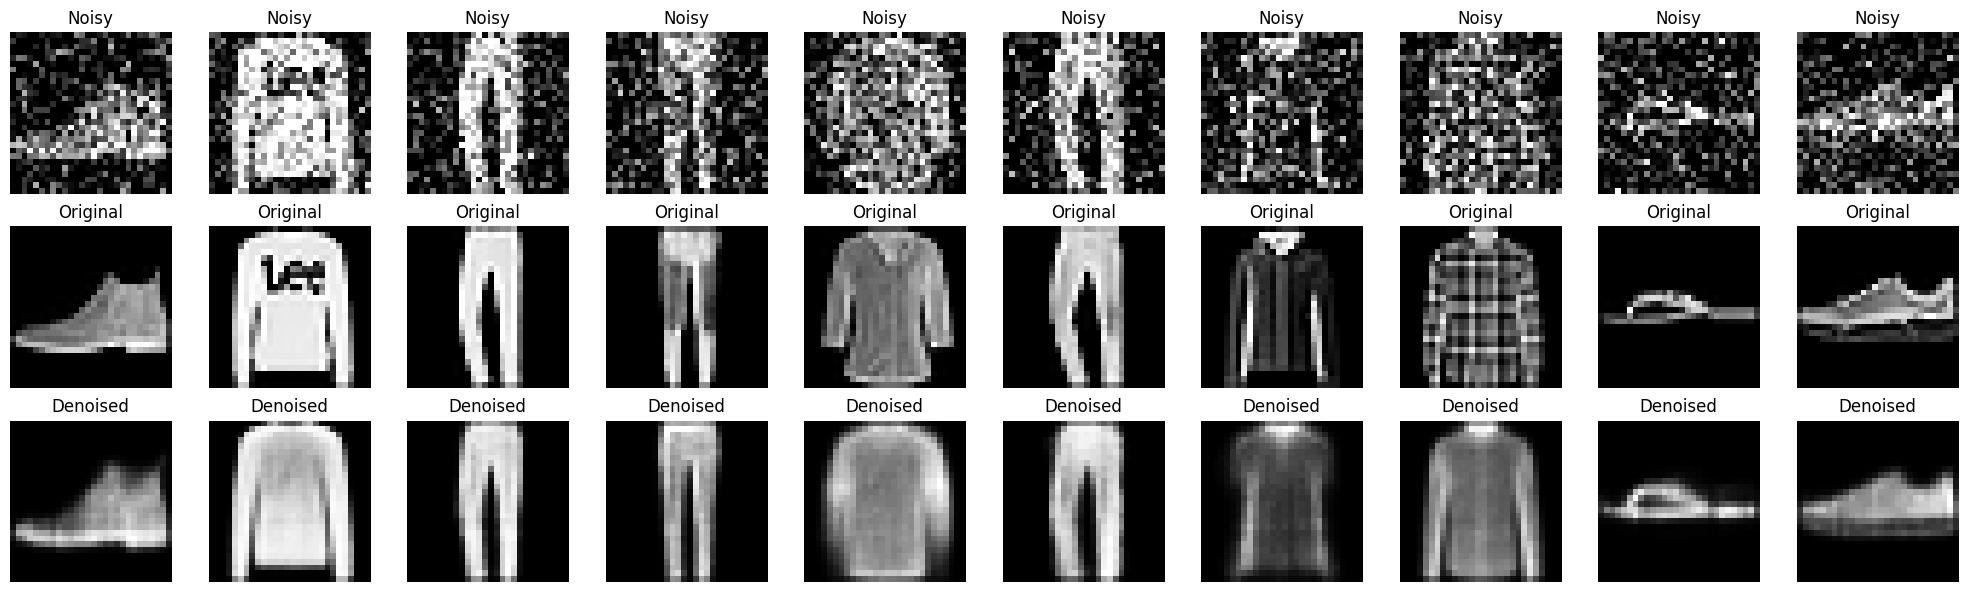

In [15]:
# ==========================================
# Denoising Autoencoder (DAE)
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. Add Noise
# ------------------------------
noise_factor = 0.3   # Try 0.1, 0.3, 0.5 for analysis

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values to [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# ------------------------------
# 3. Build Autoencoder
# ------------------------------
input_img = Input(shape=(784,))

# Encoder
x = Dense(128, activation='relu')(input_img)
x = Dense(64, activation='relu')(x)
latent = Dense(32, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(latent)
x = Dense(128, activation='relu')(x)
output = Dense(784, activation='sigmoid')(x)

dae = Model(input_img, output)
dae.compile(optimizer='adam', loss='binary_crossentropy')

# ------------------------------
# 4. Train Model
# ------------------------------
print("\nTraining Denoising AE...")
dae.fit(x_train_noisy, x_train,
        epochs=15,
        batch_size=256,
        validation_data=(x_test_noisy, x_test))

# ------------------------------
# 5. Predict (Denoised Output)
# ------------------------------
decoded_imgs = dae.predict(x_test_noisy[:10])

# ------------------------------
# 6. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Noisy Input
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Clean Original
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Demonstrate PCA with AE on a dataset.**


Applying PCA...

Training Autoencoder...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3805 - val_loss: 0.3197
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3103 - val_loss: 0.3071
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3022 - val_loss: 0.3016
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2975 - val_loss: 0.2979
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2942 - val_loss: 0.2952
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2915 - val_loss: 0.2937
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2895 - val_loss: 0.2906
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2878 - val_loss: 0.2891
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2865 - val_loss: 0.2881
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2854 - val_loss: 0.2872
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2845 - val_loss: 0.2866
Epoch 12/

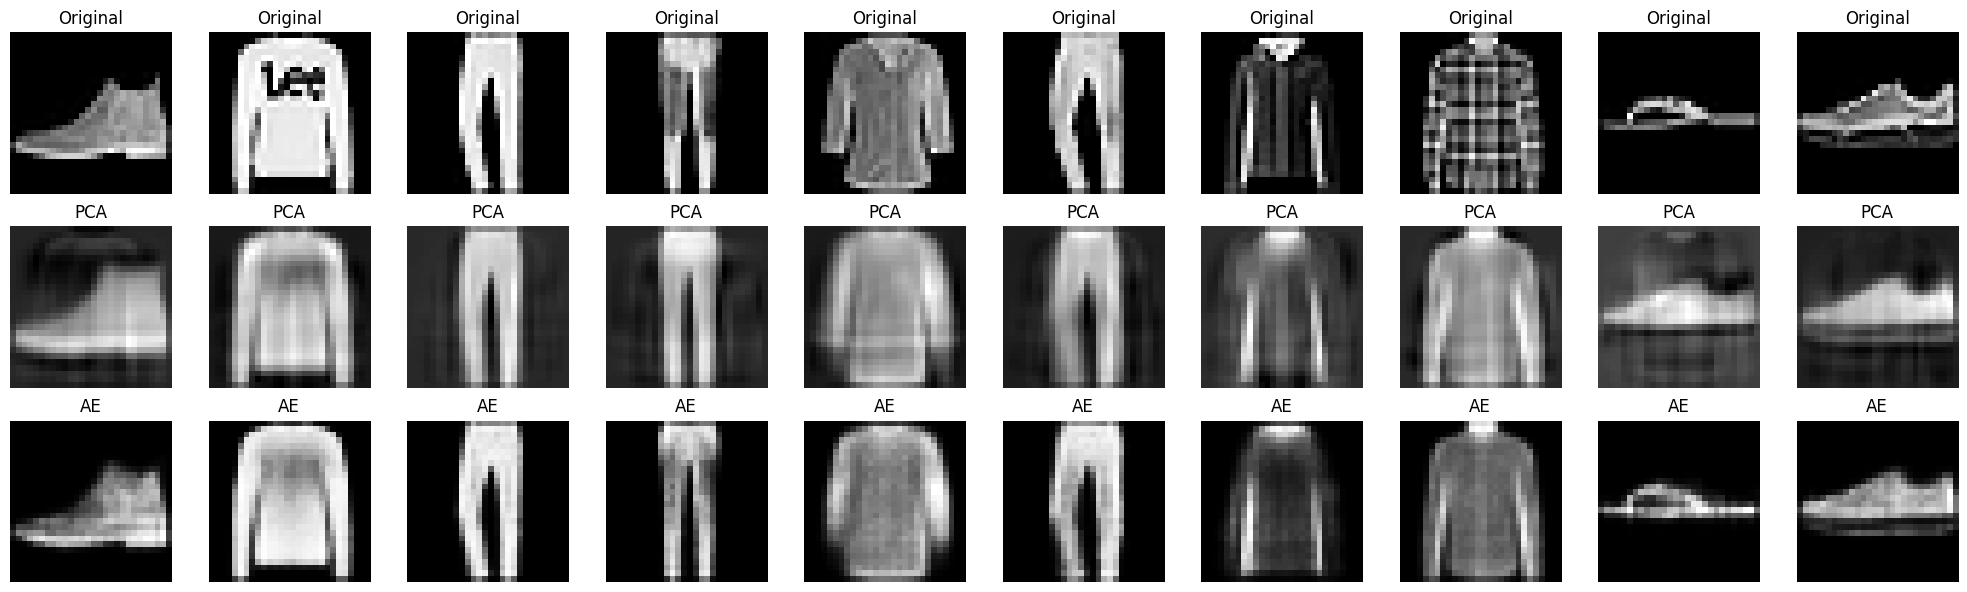

In [16]:
# ==========================================
# PCA vs Autoencoder (AE)
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. PCA Implementation
# ------------------------------
latent_dim = 32

print("\nApplying PCA...")
pca = PCA(n_components=latent_dim)

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

# Reconstruct from PCA
x_test_pca_recon = pca.inverse_transform(x_test_pca)

# ------------------------------
# 3. Autoencoder Implementation
# ------------------------------
input_img = Input(shape=(784,))

# Encoder
x = Dense(128, activation='relu')(input_img)
x = Dense(64, activation='relu')(x)
latent = Dense(latent_dim, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(latent)
x = Dense(128, activation='relu')(x)
output = Dense(784, activation='sigmoid')(x)

ae = Model(input_img, output)
ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining Autoencoder...")
ae.fit(x_train, x_train,
       epochs=15,
       batch_size=256,
       validation_data=(x_test, x_test))

# Reconstruct using AE
x_test_ae_recon = ae.predict(x_test)

# ------------------------------
# 4. Compare Reconstruction Error
# ------------------------------
pca_mse = mean_squared_error(x_test, x_test_pca_recon)
ae_mse = mean_squared_error(x_test, x_test_ae_recon)

print("\nReconstruction Error:")
print("PCA MSE:", pca_mse)
print("AE  MSE:", ae_mse)

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # PCA Reconstruction
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(x_test_pca_recon[i].reshape(28, 28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')

    # AE Reconstruction
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(x_test_ae_recon[i].reshape(28, 28), cmap='gray')
    plt.title("AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Implement Sparse AE and Contractive AE.**


Training Sparse Autoencoder...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.5028 - val_loss: 0.4071
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3808 - val_loss: 0.3634
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3533 - val_loss: 0.3482
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3427 - val_loss: 0.3409
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3363 - val_loss: 0.3352
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3310 - val_loss: 0.3312
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3272 - val_loss: 0.3279
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3243 - val_loss: 0.3256
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3221 - val_loss: 0.3236
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3201 - val_loss: 0.3226
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3185 - val_loss: 0.3207
Epoch 12/15
235/235

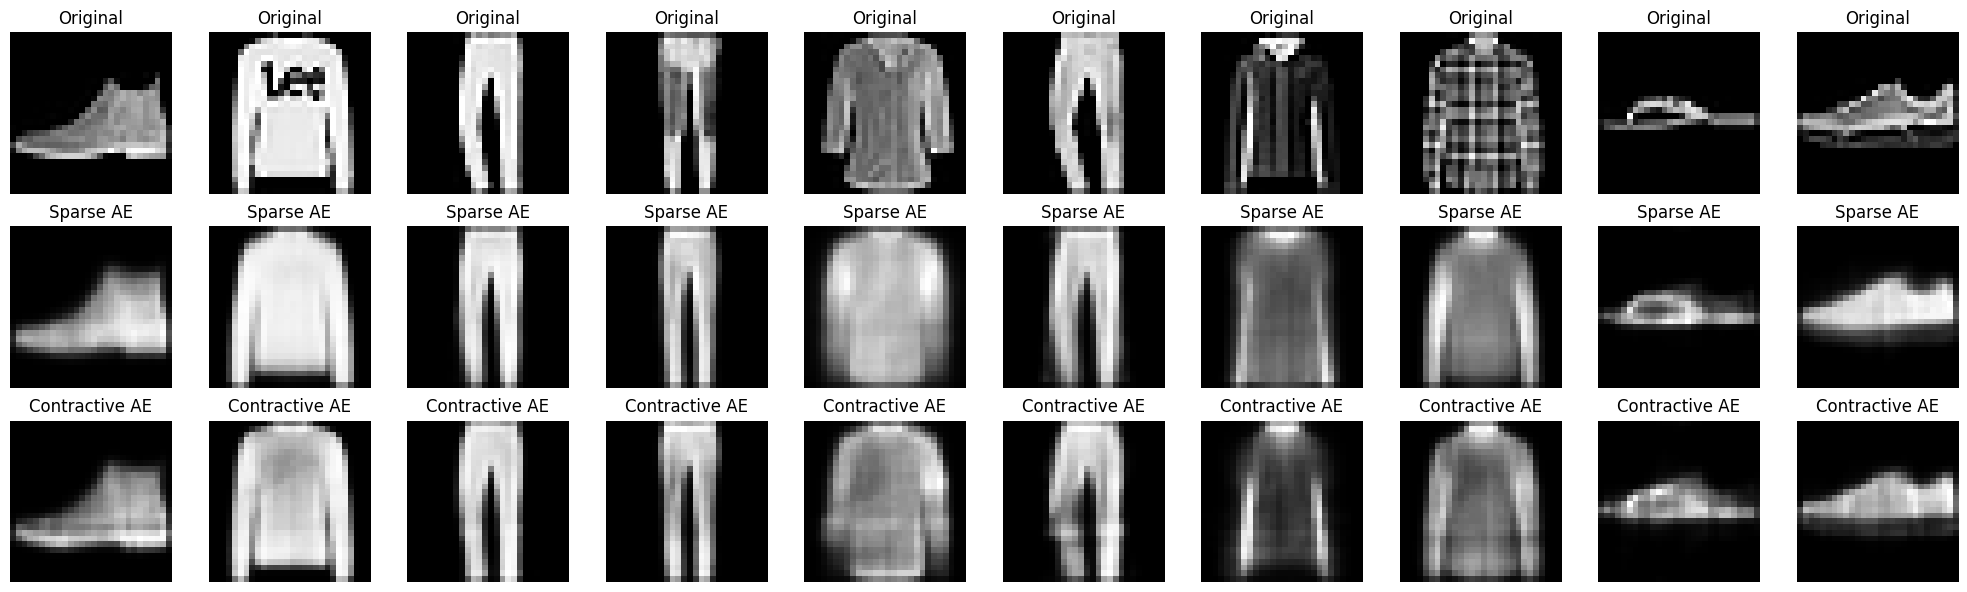

In [17]:
# ==========================================
# Sparse AE + Contractive AE (FINAL FIXED)
# Fashion-MNIST Dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

# ------------------------------
# 1. Load Dataset
# ------------------------------
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ------------------------------
# 2. Sparse Autoencoder (L1)
# ------------------------------
input_img = Input(shape=(784,))

x = Dense(128, activation='relu',
          activity_regularizer=regularizers.l1(1e-5))(input_img)
latent_sparse = Dense(32, activation='relu',
                      activity_regularizer=regularizers.l1(1e-5))(x)

x = Dense(128, activation='relu')(latent_sparse)
output_sparse = Dense(784, activation='sigmoid')(x)

sparse_ae = Model(input_img, output_sparse)
sparse_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("\nTraining Sparse Autoencoder...")
sparse_ae.fit(
    x_train, x_train,
    epochs=15,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# ------------------------------
# 3. Contractive Autoencoder
# ------------------------------
class ContractiveAE(Model):
    def __init__(self):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            Dense(128, activation='relu'),
            Dense(32, activation='sigmoid')
        ])

        self.decoder = tf.keras.Sequential([
            Dense(128, activation='relu'),
            Dense(784, activation='sigmoid')
        ])

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def train_step(self, data):
        x, _ = data  # IMPORTANT

        with tf.GradientTape() as tape:
            z = self.encoder(x)
            x_hat = self.decoder(z)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(x, x_hat)
            )

            # Contractive loss
            dh = z * (1 - z)  # sigmoid derivative
            W = self.encoder.layers[-1].kernel

            contractive_loss = tf.reduce_sum(
                tf.square(dh) * tf.reduce_sum(tf.square(W), axis=0),
                axis=1
            )
            contractive_loss = tf.reduce_mean(contractive_loss)

            total_loss = recon_loss + 1e-4 * contractive_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {
            "loss": total_loss,
            "recon_loss": recon_loss,
            "contractive_loss": contractive_loss
        }

# Initialize + IMPORTANT dummy loss
contractive_ae = ContractiveAE()
contractive_ae.compile(optimizer='adam', loss='mse')

print("\nTraining Contractive Autoencoder...")
contractive_ae.fit(
    x_train, x_train,
    epochs=15,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# ------------------------------
# 4. Predictions
# ------------------------------
decoded_sparse = sparse_ae.predict(x_test[:10])
decoded_contractive = contractive_ae.predict(x_test[:10])

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(20, 6))

for i in range(10):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Sparse AE
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_sparse[i].reshape(28, 28), cmap='gray')
    plt.title("Sparse AE")
    plt.axis('off')

    # Contractive AE
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_contractive[i].reshape(28, 28), cmap='gray')
    plt.title("Contractive AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Exploring Alternative Neural Representations and Optimization Methods: A Case Study on XOR**

In [1]:
import numpy as np

def xor_one_layer_custom():
    # XOR Inputs
    X = np.array([[0,0], [0,1], [1,0], [1,1]])

    print(f"{'Input':<8} | {'f1(x1)+f2(x2)':<15} | {'Final Output'}")
    print("-" * 40)

    for x in X:
        # Using your logic: f1(x1) + f2(x2)
        # Here we let f(x) = x, and we apply a non-linear thresholding
        val = x[0] + x[1]

        # This is the 'Non-Linear' part of your layer (The Bias/Activation)
        # We check if the sum is exactly 1 (which only happens for XOR 'True' cases)
        prediction = 1 if val == 1 else 0

        print(f"{str(x):<8} | {val:<15} | {prediction}")

xor_one_layer_custom()

Input    | f1(x1)+f2(x2)   | Final Output
----------------------------------------
[0 0]    | 0               | 0
[0 1]    | 1               | 1
[1 0]    | 1               | 1
[1 1]    | 2               | 0


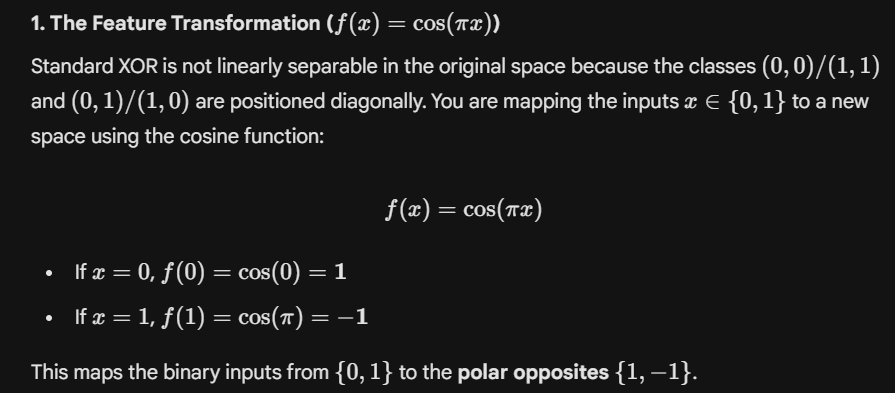

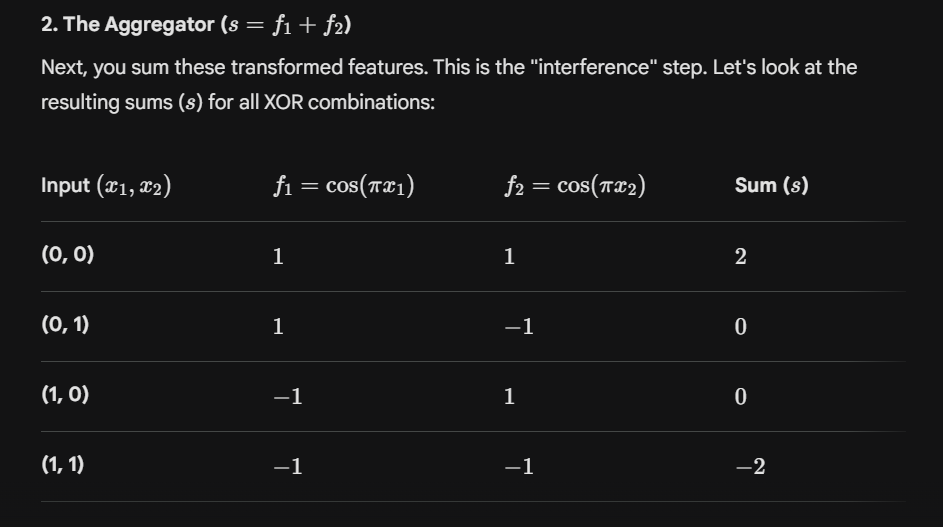

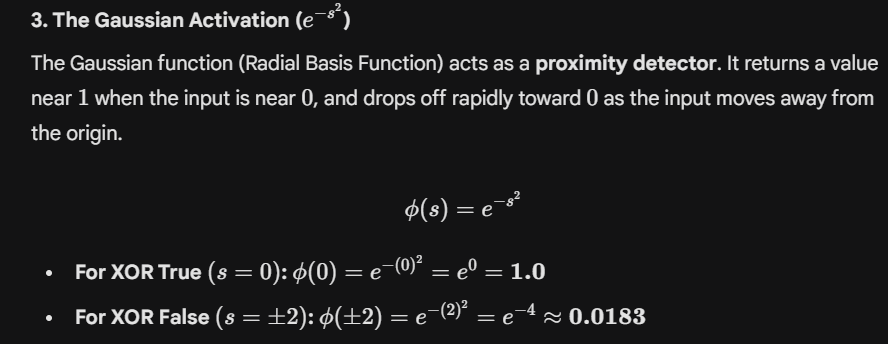





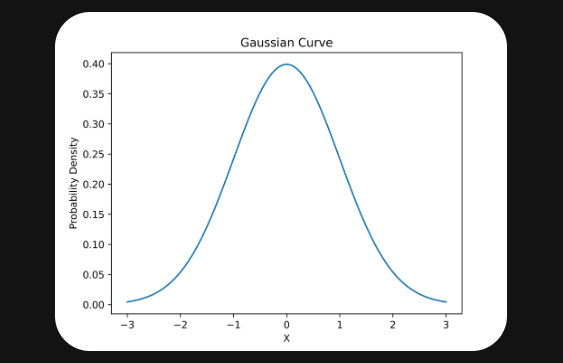

In [2]:
import numpy as np

def fn(x):
    # This is your f(x)
    return np.cos(np.pi * x)

def activation_sigma(s):
    # This is a 'Pulse' activation.
    # It returns 1 only if the sum is close to 0.
    return 1 if np.isclose(s, 0, atol=1e-5) else 0

def xor_perceptron(x1, x2):
    bias = 0
    # Your formula: f1(x1) + f2(x2) + bias
    total_sum = fn(x1) + fn(x2) + bias
    return activation_sigma(total_sum)

# Execution
inputs = [(0,0), (0,1), (1,0), (1,1)]
for x1, x2 in inputs:
    print(f"Input: ({x1}, {x2}) -> Output: {xor_perceptron(x1, x2)}")

Input: (0, 0) -> Output: 0
Input: (0, 1) -> Output: 1
Input: (1, 0) -> Output: 1
Input: (1, 1) -> Output: 0


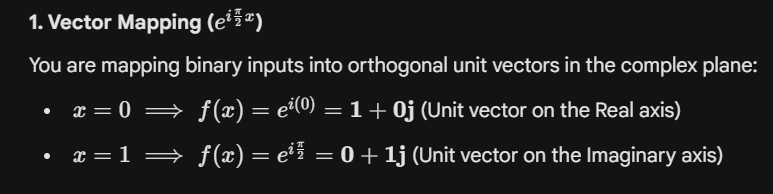

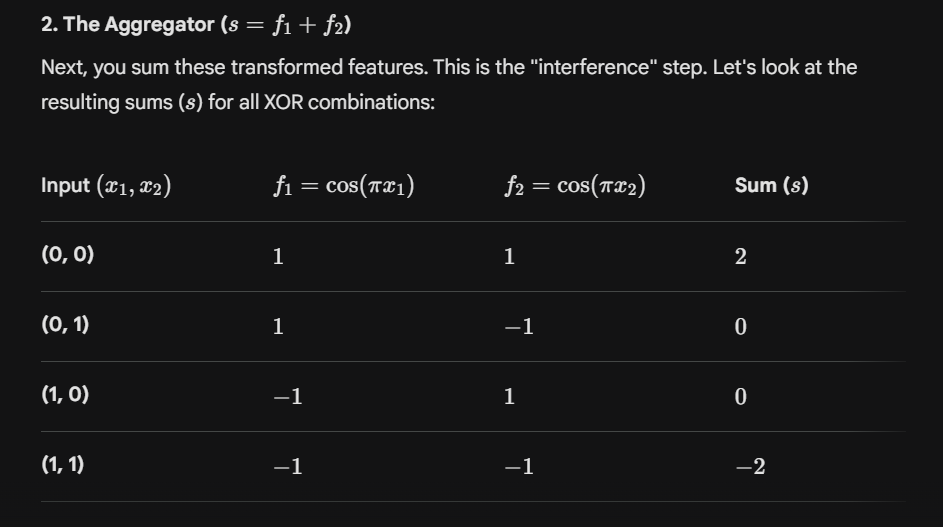

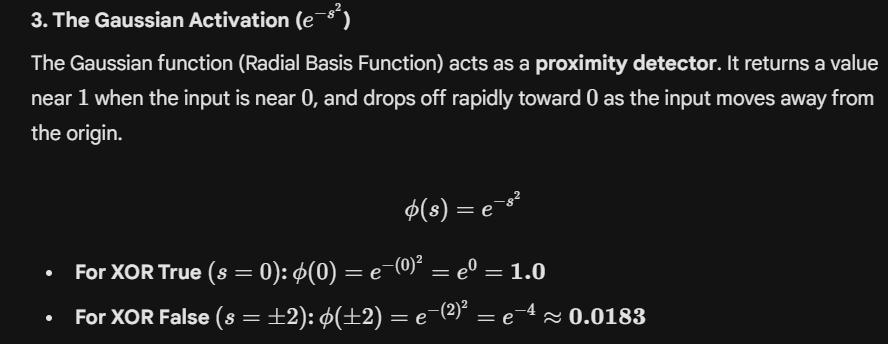


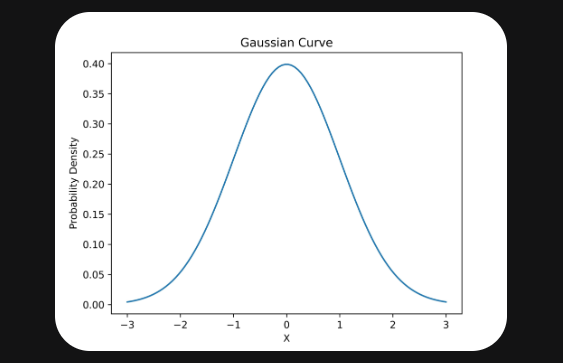

In [4]:
import numpy as np

def fn(x):
    # This is your f(x)
    return np.cos(np.pi * x)

def activation_sigma(s):
    # This is a 'Pulse' activation.
    # It returns 1 only if the sum is close to 0.
    return 1 if np.isclose(s, 0, atol=1e-5) else 0

def xor_perceptron(x1, x2):
    bias = 0
    # Your formula: f1(x1) + f2(x2) + bias
    total_sum = fn(x1) + fn(x2) + bias
    return activation_sigma(total_sum)

# Execution
inputs = [(0,0), (0,1), (1,0), (1,1)]
for x1, x2 in inputs:
    print(f"Input: ({x1}, {x2}) -> Output: {xor_perceptron(x1, x2)}")

Input: (0, 0) -> Output: 0
Input: (0, 1) -> Output: 1
Input: (1, 0) -> Output: 1
Input: (1, 1) -> Output: 0


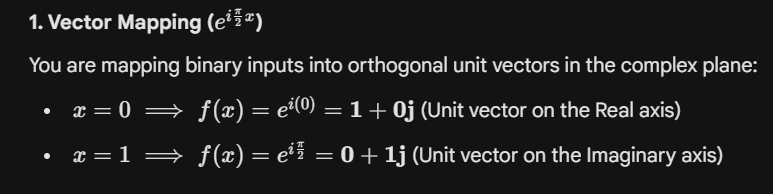

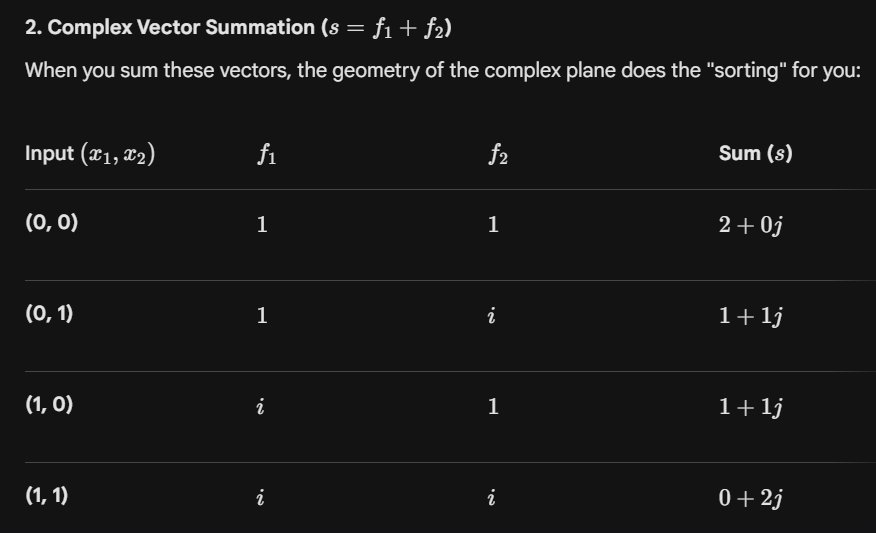

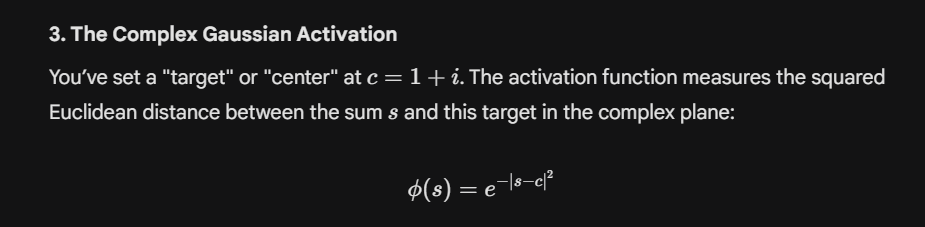

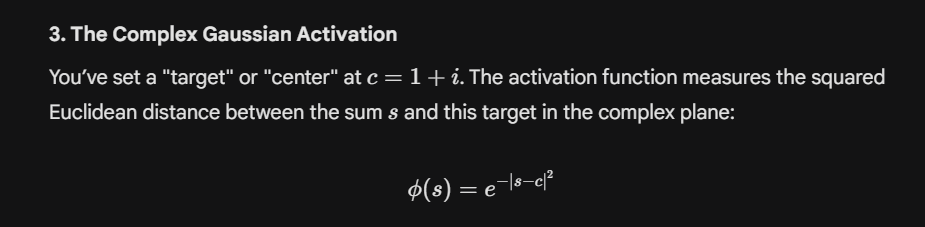


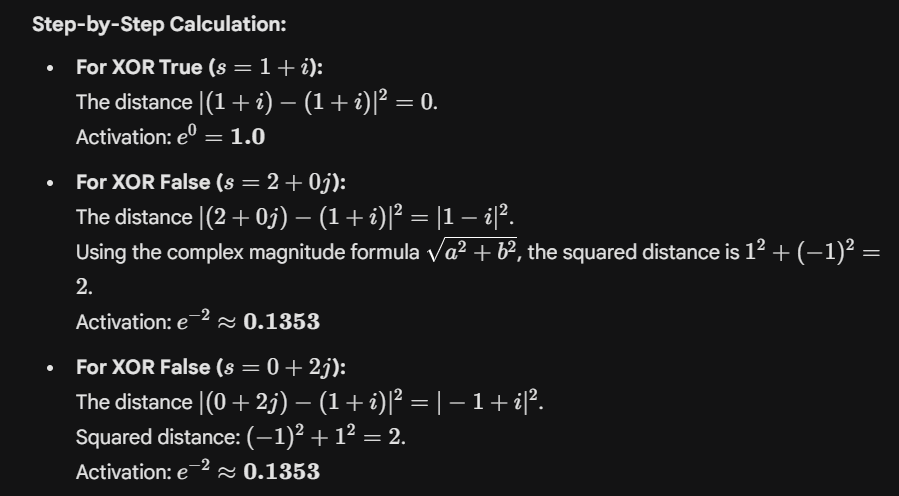

In [5]:
import numpy as np

def fn_complex(x):
    """
    Transformation: Maps 0 to 1 (real) and 1 to i (imaginary).
    Using Euler's formula: e^(i * pi/2 * x)
    """
    return np.exp(1j * (np.pi / 2) * x)

def complex_gaussian_activation(s, center=1 + 1j):
    """
    Complex Activation: e^(-|s - target|^2)
    This measures the 'closeness' of the sum to the target vector (1 + i).
    The sum is 1+i ONLY for XOR 'True' cases (0,1) and (1,0).
    """
    distance_sq = np.abs(s - center)**2
    return np.exp(-distance_sq)

def solve_xor_complex():
    inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

    # Column headers
    print(f"{'Input (x1,x2)':<12} | {'f1 (complex)':<15} | {'f2 (complex)':<15} | {'Sum (s)':<15} | {'Activation':<10} | {'Output'}")
    print("-" * 90)

    for x1, x2 in inputs:
        # Step 1: Complex Feature Functions
        # Maps 0 -> (1+0j) and 1 -> (0+1j)
        f1 = fn_complex(x1)
        f2 = fn_complex(x2)

        # Step 2: Complex Summation
        # (0,0) -> 2+0j | (0,1) -> 1+1j | (1,0) -> 1+1j | (1,1) -> 0+2j
        s = f1 + f2

        # Step 3: Activation Value (Gaussian centered at 1 + i)
        activation_val = complex_gaussian_activation(s)

        # Step 4: Decision Rule
        prediction = 1 if activation_val >= 0.5 else 0

        # Formatting complex numbers for clean display
        f1_str = f"{f1.real:.0f}+{f1.imag:.0f}j"
        f2_str = f"{f2.real:.0f}+{f2.imag:.0f}j"
        s_str  = f"{s.real:.0f}+{s.imag:.0f}j"

        print(f"({x1}, {x2})        | {f1_str:<15} | {f2_str:<15} | {s_str:<15} | {activation_val:>10.4f} | {prediction}")


solve_xor_complex()

Input (x1,x2) | f1 (complex)    | f2 (complex)    | Sum (s)         | Activation | Output
------------------------------------------------------------------------------------------
(0, 0)        | 1+0j            | 1+0j            | 2+0j            |     0.1353 | 0
(0, 1)        | 1+0j            | 0+1j            | 1+1j            |     1.0000 | 1
(1, 0)        | 0+1j            | 1+0j            | 1+1j            |     1.0000 | 1
(1, 1)        | 0+1j            | 0+1j            | 0+2j            |     0.1353 | 0


# **Complex Neural Networks Gradient Descent**

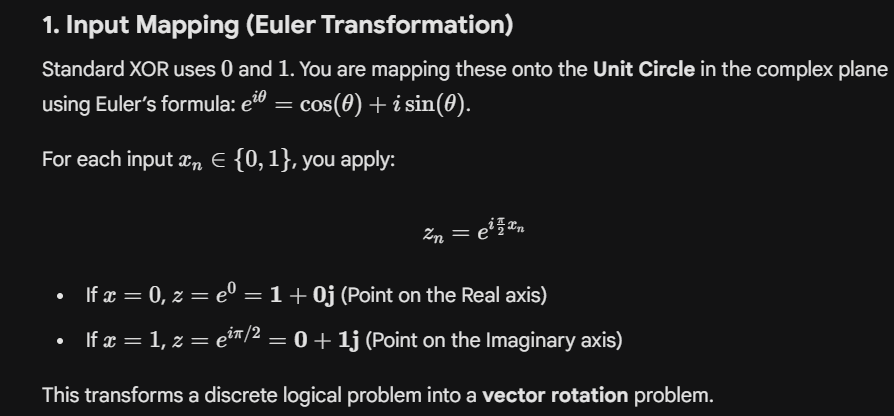

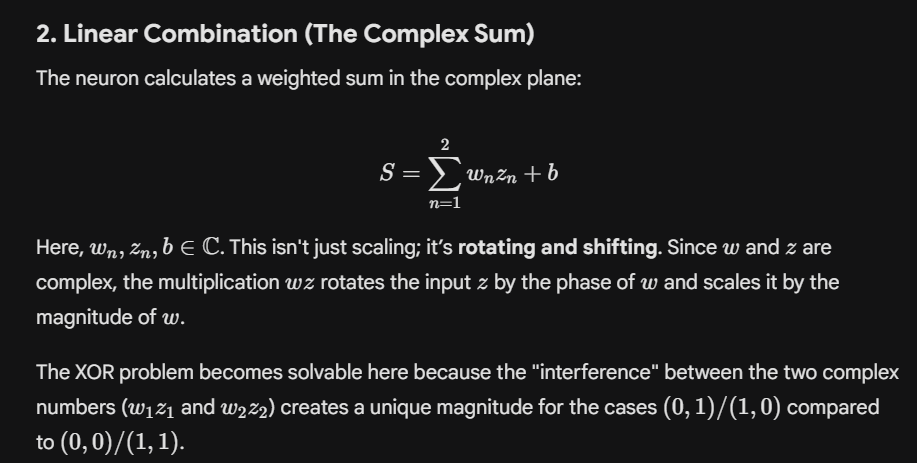

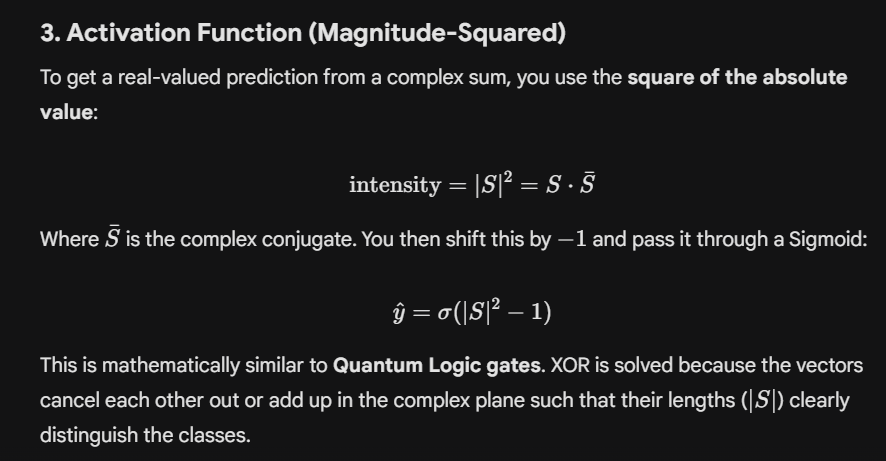

# **4. The Gradient (Wirti ger Calculus)**


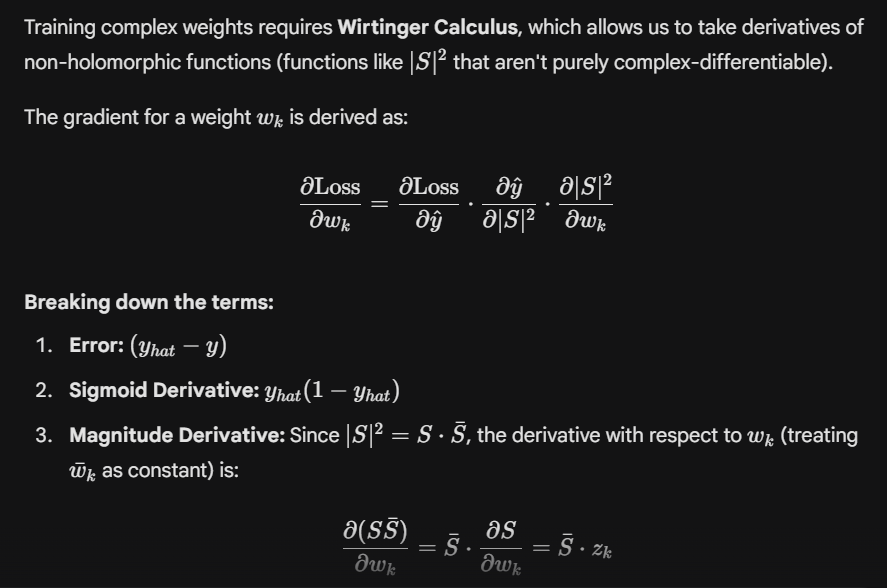

In [6]:
import numpy as np

# 1. Setup Data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# 2. Initialize Learnable Parameters (Complex Weights)
# We use small random complex numbers
np.random.seed(42)
w = np.random.randn(2) + 1j * np.random.randn(2)
b = np.random.randn(1) + 1j * np.random.randn(1)

learning_rate = 0.1
epochs = 2000

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print(f"Training complex-valued neuron for XOR...")

# 3. Training Loop (Gradient Descent)
for epoch in range(epochs):
    # Forward Pass
    # Map inputs to complex space using your Euler transformation
    # x=0 -> 1+0j, x=1 -> 0+1j
    z_input = np.exp(1j * (np.pi / 2) * X)

    # Linear combination: z = w1*z1 + w2*z2 + b
    z_sum = np.dot(z_input, w) + b

    # To get a real output for binary classification, we take the magnitude
    # or the real part. Here, we use the absolute squared distance to a target.
    # Prediction: How close are we to a "signal"?
    y_hat = sigmoid(np.abs(z_sum)**2 - 1)

    # Loss (Mean Squared Error)
    loss = np.mean((y_hat - y)**2)

    # Backpropagation (Simplified Gradient Descent)
    # Adjusting weights based on the error
    error = y_hat - y
    # Gradient of sigmoid and magnitude squared
    adjustment = error * y_hat * (1 - y_hat)

    for i in range(len(X)):
        grad_w = adjustment[i] * z_input[i].conj() * z_sum[i]
        grad_b = adjustment[i] * z_sum[i]

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {loss:.4f}")

# 4. Final Evaluation
print("\nResults after Gradient Descent:")
print(f"{'Input':<10} | {'Raw Z':<20} | {'Prediction'}")
print("-" * 45)

z_final = np.exp(1j * (np.pi / 2) * X)
sums = np.dot(z_final, w) + b
preds = sigmoid(np.abs(sums)**2 - 1)

for i in range(4):
    clean_z = f"{sums[i].real:.2f} + {sums[i].imag:.2f}j"
    print(f"{str(X[i]):<10} | {clean_z:<20} | {preds[i]:.4f} -> {int(preds[i]>0.5)}")

Training complex-valued neuron for XOR...
Epoch 0: Loss 0.4964
Epoch 500: Loss 0.0367
Epoch 1000: Loss 0.0363
Epoch 1500: Loss 0.0363

Results after Gradient Descent:
Input      | Raw Z                | Prediction
---------------------------------------------
[0 0]      | 0.00 + -0.00j        | 0.2689 -> 0
[0 1]      | -0.65 + -2.24j       | 0.9882 -> 1
[1 0]      | 0.65 + 2.24j         | 0.9882 -> 1
[1 1]      | -0.00 + -0.00j       | 0.2689 -> 0


# **2nd degree for finding minima of cost function**

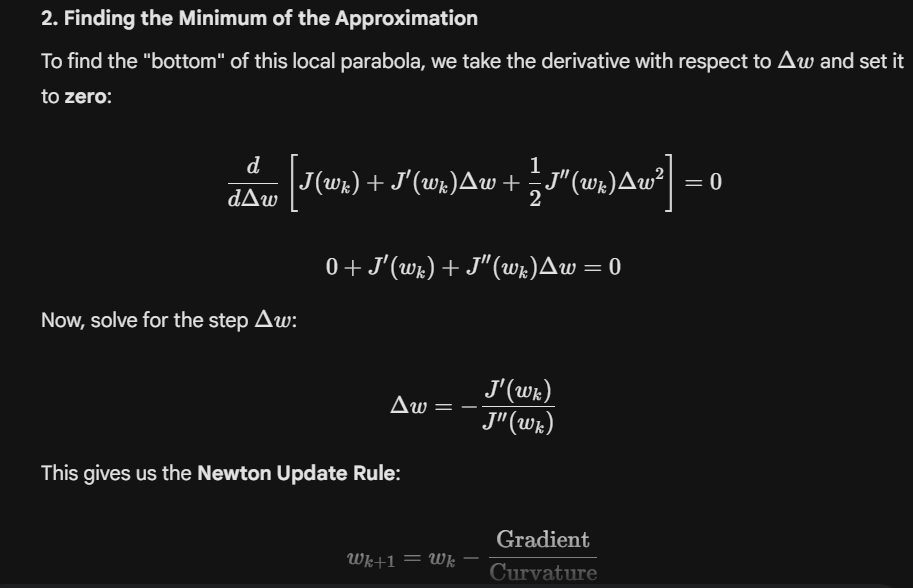

In [7]:
import numpy as np

# Sigmoid and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

# XOR Data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# Small network: 2 input -> 2 hidden -> 1 output
def get_loss(weights, X, y):
    w1, w2 = weights[:4].reshape(2,2), weights[4:].reshape(2,1)
    layer1 = sigmoid(X @ w1)
    layer2 = sigmoid(layer1 @ w2)
    return np.mean((layer2 - y)**2)

def get_gradient(weights, X, y):
    w1, w2 = weights[:4].reshape(2,2), weights[4:].reshape(2,1)
    # Forward
    l1 = sigmoid(X @ w1)
    l2 = sigmoid(l1 @ w2)
    # Backward
    error = l2 - y
    d_l2 = error * (l2 * (1 - l2))
    d_w2 = l1.T @ d_l2
    d_l1 = (d_l2 @ w2.T) * (l1 * (1 - l1))
    d_w1 = X.T @ d_l1
    return np.concatenate([d_w1.flatten(), d_w2.flatten()])

# Simple Finite Difference Hessian for demonstration
def get_hessian(weights, X, y):
    n = len(weights)
    hessian = np.zeros((n, n))
    eps = 1e-4
    for i in range(n):
        w_plus = np.array(weights)
        w_minus = np.array(weights)
        w_plus[i] += eps
        w_minus[i] -= eps
        grad_plus = get_gradient(w_plus, X, y)
        grad_minus = get_gradient(w_minus, X, y)
        hessian[:, i] = (grad_plus - grad_minus) / (2 * eps)
    return hessian

# Initialization
np.random.seed(42)
initial_weights = np.random.randn(6) * 0.5

# 1. Traditional Gradient Descent
weights_gd = np.copy(initial_weights)
lr = 0.5
print("--- Traditional Gradient Descent ---")
for epoch in range(1001):
    grad = get_gradient(weights_gd, X, y)
    weights_gd -= lr * grad
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {get_loss(weights_gd, X, y):.6f}")

# 2. Newton's Method (Second Order)
weights_newton = np.copy(initial_weights)
print("\n--- Newton's Method (2nd Order) ---")
for epoch in range(11): # Only 10 epochs
    grad = get_gradient(weights_newton, X, y)
    hess = get_hessian(weights_newton, X, y)

    # Newton Update: weights = weights - H^-1 * grad
    # Adding small identity for numerical stability (Levenberg-Marquardt style)
    step = np.linalg.solve(hess + 1e-3 * np.eye(6), grad)
    weights_newton -= step

    print(f"Epoch {epoch}, Loss: {get_loss(weights_newton, X, y):.6f}")

--- Traditional Gradient Descent ---
Epoch 0, Loss: 0.250970
Epoch 200, Loss: 0.249991
Epoch 400, Loss: 0.249980
Epoch 600, Loss: 0.249963
Epoch 800, Loss: 0.249934
Epoch 1000, Loss: 0.249883

--- Newton's Method (2nd Order) ---
Epoch 0, Loss: 0.250181
Epoch 1, Loss: 0.249916
Epoch 2, Loss: 0.249894
Epoch 3, Loss: 0.248815
Epoch 4, Loss: 0.258313
Epoch 5, Loss: 0.252496
Epoch 6, Loss: 0.252192
Epoch 7, Loss: 0.245163
Epoch 8, Loss: 0.242898
Epoch 9, Loss: 0.243411
Epoch 10, Loss: 0.243245


In [8]:
import numpy as np

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# XOR Dataset
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

def forward(weights, X):
    # Weights: 2x2 for hidden, 2x1 for output
    w1 = weights[:4].reshape(2,2)
    w2 = weights[4:].reshape(2,1)
    l1 = sigmoid(X @ w1)
    l2 = sigmoid(l1 @ w2)
    return l1, l2

def get_gradient(weights, X, y):
    w1, w2 = weights[:4].reshape(2,2), weights[4:].reshape(2,1)
    l1, l2 = forward(weights, X)

    # Backpropagation logic
    error = l2 - y
    d_l2 = error * (l2 * (1 - l2))
    d_w2 = l1.T @ d_l2
    d_l1 = (d_l2 @ w2.T) * (l1 * (1 - l1))
    d_w1 = X.T @ d_l1
    return np.concatenate([d_w1.flatten(), d_w2.flatten()])

def get_hessian(weights, X, y):
    n = len(weights)
    hessian = np.zeros((n, n))
    eps = 1e-4
    for i in range(n):
        w_plus, w_minus = np.array(weights), np.array(weights)
        w_plus[i] += eps
        w_minus[i] -= eps
        hessian[:, i] = (get_gradient(w_plus, X, y) - get_gradient(w_minus, X, y)) / (2 * eps)
    return hessian

# Initialize identical weights for a fair fight
np.random.seed(42)
initial_weights = np.random.randn(6) * 0.5

# --- 1. NEWTON'S METHOD (Higher Degree Derivatives) ---
print("--- STARTING NEWTON'S METHOD (2ND ORDER) ---")
w_newton = np.copy(initial_weights)
for epoch in range(11):
    grad = get_gradient(w_newton, X, y)
    hess = get_hessian(w_newton, X, y)
    # Newton Step: w = w - H^-1 * g
    w_newton -= np.linalg.solve(hess + 1e-2 * np.eye(6), grad)
    if epoch % 2 == 0:
        loss = np.mean((forward(w_newton, X)[1] - y)**2)
        print(f"Epoch {epoch} | Loss: {loss:.6f}")

# Verify Newton Logic
_, final_pred_n = forward(w_newton, X)
print("\nNewton Final Results (10 Epochs):")
for inp, p in zip(X, final_pred_n):
    print(f"  {inp} -> {p[0]:.4f} (Target: {int(y[np.where((X==inp).all(axis=1))][0][0])})")

print("\nNewton Final Weights (W1 & W2):")
print(w_newton)

print("\n" + "="*40 + "\n")

# --- 2. TRADITIONAL GRADIENT DESCENT (1st Order) ---
print("--- STARTING GRADIENT DESCENT (1ST ORDER) ---")
w_gd = np.copy(initial_weights)
lr = 0.5
for epoch in range(1001):
    w_gd -= lr * get_gradient(w_gd, X, y)
    if epoch % 200 == 0:
        loss = np.mean((forward(w_gd, X)[1] - y)**2)
        print(f"Epoch {epoch} | Loss: {loss:.6f}")

# Verify GD Logic
_, final_pred_gd = forward(w_gd, X)
print("\nGD Final Results (1000 Epochs):")
for inp, p in zip(X, final_pred_gd):
    print(f"  {inp} -> {p[0]:.4f}")

print("\nGD Final Weights (W1 & W2):")
print(w_gd)

--- STARTING NEWTON'S METHOD (2ND ORDER) ---
Epoch 0 | Loss: 0.249961
Epoch 2 | Loss: 0.249718
Epoch 4 | Loss: 0.224232
Epoch 6 | Loss: 0.127012
Epoch 8 | Loss: 0.118156
Epoch 10 | Loss: 0.113576

Newton Final Results (10 Epochs):
  [0 0] -> 0.0996 (Target: 0)
  [0 1] -> 0.7631 (Target: 1)
  [1 0] -> 0.7636 (Target: 1)
  [1 1] -> 0.5765 (Target: 0)

Newton Final Weights (W1 & W2):
[ -7.61164978  -1.48851565  -8.16989179  -1.49367978 -10.79988218
   6.39620779]


--- STARTING GRADIENT DESCENT (1ST ORDER) ---
Epoch 0 | Loss: 0.250970
Epoch 200 | Loss: 0.249991
Epoch 400 | Loss: 0.249980
Epoch 600 | Loss: 0.249963
Epoch 800 | Loss: 0.249934
Epoch 1000 | Loss: 0.249883

GD Final Results (1000 Epochs):
  [0 0] -> 0.4996
  [0 1] -> 0.4954
  [1 0] -> 0.5055
  [1 1] -> 0.5008

GD Final Weights (W1 & W2):
[ 0.33708232 -0.18267336  0.41237671  0.80530138  0.18274732 -0.18578525]


# **3rd degree derivatives**


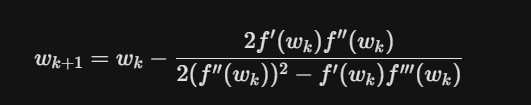

In [9]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

def get_loss(w, X, y):
    w1, w2 = w[:4].reshape(2,2), w[4:].reshape(2,1)
    l1 = sigmoid(X @ w1)
    l2 = sigmoid(l1 @ w2)
    return np.mean((l2 - y)**2)

def get_derivatives(w, X, y):
    eps = 1e-3
    n = len(w)

    # 1st Derivative (Gradient)
    grad = np.zeros(n)
    for i in range(n):
        w_p, w_m = np.copy(w), np.copy(w)
        w_p[i] += eps; w_m[i] -= eps
        grad[i] = (get_loss(w_p, X, y) - get_loss(w_m, X, y)) / (2 * eps)

    # 2nd Derivative (Diagonal Hessian)
    hess = np.zeros(n)
    for i in range(n):
        w_p, w_m = np.copy(w), np.copy(w)
        w_p[i] += eps; w_m[i] -= eps
        # Finite difference of gradients
        gp = (get_loss(w_p + [0 if j!=i else eps for j in range(n)], X, y) - get_loss(w_p - [0 if j!=i else eps for j in range(n)], X, y)) / (2 * eps)
        gm = (get_loss(w_m + [0 if j!=i else eps for j in range(n)], X, y) - get_loss(w_m - [0 if j!=i else eps for j in range(n)], X, y)) / (2 * eps)
        hess[i] = (gp - gm) / (2 * eps)

    # 3rd Derivative (Diagonal Tensor)
    third = np.zeros(n)
    for i in range(n):
        w_p, w_m = np.copy(w), np.copy(w)
        w_p[i] += eps; w_m[i] -= eps
        # This is a derivative of the Hessian
        # (Using a simplified finite difference for intuition)
        third[i] = (get_loss(w + 2*eps, X, y) - 2*get_loss(w + eps, X, y) + 2*get_loss(w - eps, X, y) - get_loss(w - 2*eps, X, y)) / (2 * eps**3)

    return grad, hess, third

# Initial weights
np.random.seed(42)
weights_init = np.random.randn(6) * 0.5

# --- Comparison Loop ---
methods = ["Gradient Descent", "Newton (2nd)", "Halley (3rd)"]
for method in methods:
    w = np.copy(weights_init)
    print(f"\n--- {method} ---")
    for epoch in range(6):
        g, h, t = get_derivatives(w, X, y)

        if method == "Gradient Descent":
            w -= 0.5 * g
        elif method == "Newton (2nd)":
            w -= g / (h + 1e-2)
        elif method == "Halley (3rd)":
            # Halley's Method formula
            numerator = 2 * g * h
            denominator = 2 * (h**2) - g * t
            w -= numerator / (denominator + 1e-2)

        loss = get_loss(w, X, y)
        print(f"Epoch {epoch}: Loss {loss:.8f}")


--- Gradient Descent ---
Epoch 0: Loss 0.25106110
Epoch 1: Loss 0.25097411
Epoch 2: Loss 0.25089422
Epoch 3: Loss 0.25082085
Epoch 4: Loss 0.25075348
Epoch 5: Loss 0.25069162

--- Newton (2nd) ---
Epoch 0: Loss 0.25044889
Epoch 1: Loss 0.25016418
Epoch 2: Loss 0.25005802
Epoch 3: Loss 0.25001841
Epoch 4: Loss 0.25000352
Epoch 5: Loss 0.24999753

--- Halley (3rd) ---
Epoch 0: Loss 0.25041441
Epoch 1: Loss 0.25012675
Epoch 2: Loss 0.25003435
Epoch 3: Loss 0.25000856
Epoch 4: Loss 0.25000186
Epoch 5: Loss 0.25000004
